<a href="https://colab.research.google.com/github/gardenstorm/tweetlens/blob/main/tweetlens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Summer 2025 Build Project - TweetLens: Unveiling Insights from Twitter Data

## My topic: Internet Privacy

## Data set
After choosing a topic, I searched for a dataset on Kaggle. What I found was the [Internet Privacy Poll](https://www.kaggle.com/datasets/econdata/internet-privacy-poll), from a [July 2013 Pew Internet and American Life Project](https://www.pewresearch.org/internet/2013/09/05/anonymity-privacy-and-security-online/) poll on Internet anonymity and privacy.

## Questions to ask

- Sentiment: how do people feel?
 - How does it compare to the past?
- Topics: what are people talking about?
 - Anything outside the big news topics?
- News: What events are going on regarding privacy?
- What is the state of internet privacy outside the US?
- What kinds of businesses are working with privacy in mind?

## Resources referenced
- [Tweepy Documentation](https://docs.tweepy.org/en/stable/index.html)
- [A comprehensive guide for using the Twitter API v2 with Tweepy in Python](https://dev.to/xdevs/a-comprehensive-guide-for-using-the-twitter-api-v2-using-tweepy-in-python-15d9)
- [twitter-tweepy.ipynb - Colab](https://colab.research.google.com/github/kirenz/twitter-tweepy/blob/main/twitter-tweepy.ipynb#scrollTo=9SHlxUCsr0vz)
- [tweepy | DeepWiki](https://deepwiki.com/tweepy/tweepy/6.2-paginator)
- [Tweepy pagination? | StackOverflow post](https://stackoverflow.com/questions/72016766/tweepy-only-lets-me-get-100-results-how-do-i-get-more-ive-read-about-paginati)
- [How to combine CSV files using Python? | Ask Python post](https://www.askpython.com/python-modules/pandas/combine-csv-files-using-python)
- [Data Cleaning in Pandas video](https://www.youtube.com/watch?v=bDhvCp3_lYw)
- [tweet-preprocessor](https://pypi.org/project/tweet-preprocessor/#description)
- [Removing stop words with NLTK in Python | GeeksforGeeks](https://www.geeksforgeeks.org/nlp/removing-stop-words-nltk-python/)
- [Python Word Clouds Tutorial | DataCamp](https://www.datacamp.com/tutorial/wordcloud-python)
- And, of course, the documentation for [Pandas](https://pandas.pydata.org/pandas-docs/stable/index.html), [matplotlib](https://matplotlib.org/stable/users/explain/axes/legend_guide.html#legend-guide), [TextBlob](https://textblob.readthedocs.io/en/dev/quickstart.html#sentiment-analysis), and [WordCloud](https://amueller.github.io/word_cloud/index.html)

## Setup

### Load and install libraries
These are all the libraries I used for this project.

In [ ]:
# main libraries
import pandas as pd
import numpy as np

# tweet pulling
import tweepy

# tweet cleaning
!pip install tweet-preprocessor
import preprocessor as pt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt_tab')
import re

# sentiment analysis
import textblob
from textblob import TextBlob

# word cloud
from PIL import Image
from wordcloud import WordCloud, ImageColorGenerator

# plot graphs
import matplotlib.pyplot as plt
%matplotlib inline

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Authentication for Twitter/X API

I used Google Colab's Secrets feature to securely save my X developer tokens for use with tweepy. Two X developer accounts were needed to get around the 100 tweet per month limit. I used up one token, then used the next one.

In [ ]:
from google.colab import userdata
my_token = userdata.get('my_token')
second_token = userdata.get('second_token')

In [ ]:
#client = tweepy.Client(bearer_token = my_token)
client = tweepy.Client(bearer_token = second_token)

---

## Summary

This section is a summary of the code I used and my process.

### Grab and save tweets
To get and save tweets, I created a function using tweepy's `search_recent_tweets()`. Parameters were set for the query, number of tweets, and the name of the csv file.

The rate limit made it difficult for me to use paginaton, so I pulled tweets 10 at a time instead. My last sets of pulls were around 40 per request to save time, though.

🌠 A fun thing I noticed: When pulling more than 10 tweets at a time, you will likely receive less than what you requested. For example, when I requested 40 tweets, I got back 37 tweets.

It also took me a long time to realize the rate limit from the free tier is what was preventing me from using pagination. If I had realized sooner, I would have tried using the next token approach.

These tests were done between July 19 and July 27, with most tweets pulled on July 27.

In [ ]:
def grab_tweets(my_query, num_results, file_name):
  tweets = client.search_recent_tweets(query=query, max_results=num_results)
  print(tweets)
  tweet_set = pd.DataFrame(tweets)
  tweet_set.to_csv(file_name)

### AI Generated Tweets

I tested using Hugging Face's Pipeline with the gpt2 model to generate tweets based on an example from the weekly workshop and the [Hugging Face Pipeline documentation](https://huggingface.co/docs/transformers/en/pipeline_tutorial). My first 2 attempts were to get a feel for how it works and the last attempt was to see it would compare to actual tweets about digital privacy. The results were a bit goofy, so I would need to test different models and prompts before using AI generated tweets. Therefore, I felt it was best to use real tweets.

### Consolidate tweets
For consolidating all the csv files, I created another function using append and concat. I ran this a few times until I had one file with all the tweets.

It took me a while to get the hang of creating and saving CSV files because I am new to Pandas.

In [ ]:
def combine_csv_files(file_names_list, new_file_name):
  list = []
  for file in file_names_list:
    list.append(pd.read_csv(file))
  df_res = pd.concat(list, ignore_index=True)
  df_res
  df_res.to_csv(new_file_name)

### Clean tweets
To clean the tweets, I used tweet-preprocessor and NLTK within a few functions I created.

Before I reorganized my data in Excel, I removed excess columns, NaN values, and data that was not tweets. Data was reorganized because the large number of columns and inconsistent row lengths made coding more difficult than necessary. (I detail this more in the Sentiment Analysis section.)

First, I loaded the final CSV file into a dataframe.

In [ ]:
to_be_cleaned_df = pd.read_csv('tweets-only-better.csv').dropna(axis=1)

Second, I used a function with a loop so tweet-preprocessor could remove URLs, emojis, and smileys from each tweet. Each cleaned tweet was then added into a new dataframe.

Mentions were kept in ⬇this function for use in the word cloud.

In [ ]:
def use_tweet_preproessor(df):
  # parts to remove from tweets
  pt.set_options(pt.OPT.URL, pt.OPT.EMOJI, pt.OPT.SMILEY)

  # empty df to fill
  empty_frame = pd.DataFrame()

  # loop to apply cleaner to desired df
  for x in df.columns:
    a_col = str(x)
    empty_frame[a_col] = df[a_col].apply(pt.clean)
  return empty_frame

⬇This function is the same as above, but with mentions removed for sentiment analysis.

In [1]:
def remove_mentions(df):
  # parts to remove from tweets
  pt.set_options(pt.OPT.URL, pt.OPT.EMOJI, pt.OPT.SMILEY, pt.OPT.MENTION)

  # empty df to fill
  empty_frame = pd.DataFrame()

  # loop to apply cleaner to desired df
  for x in df.columns:
    a_col = str(x)
    empty_frame[a_col] = df[a_col].apply(pt.clean)
  return empty_frame

Third, I created a function using NLTK to remove stopwords and the replace method from Pandas to remove punctuation.

In [ ]:
def clean_stopwords(processed_df):
  stop_words = set(stopwords.words('english'))
  tweet_tokens = processed_df.apply(lambda col: col.str.lower())

  def remove_stopwords(text):
    if not isinstance(text, str):
      return ' '
    words = text.split()
    no_stops = [word for word in words if word.lower() not in stop_words]
    return ' '.join(no_stops)
  new_df = tweet_tokens.map(remove_stopwords).replace(to_replace='[^A-Za-z\s]', value='', regex=True)
  return new_df

Lastly, I applied the functions I created to the dataframe containing the tweets. This resulted in 2 dataframes: one with mentions and one without mentions.

In [ ]:
# generate dfs!
mentions_kept = use_tweet_preproessor(to_be_cleaned_df)
mentions_gone = remove_mentions(to_be_cleaned_df)
# cleaned tweets
preprocessed_tweets = clean_stopwords(mentions_gone)
preprocessed_tweets2  = clean_stopwords(mentions_kept)

### Sentiment Analysis
I used TextBlob and Pandas to do sentiment analysis and plot the results.

The code I used was slightly modified from a live demo example in our weekly workshop. My main changes were:

1. Switching apply with map.
2. Using pyplot to move the legend to the side of the graph.

In addition, running senitment analysis is what prompted me to reorganize my code in Excel. Before reorganizing, the CSV was 11 rows, 36 columns, and had an uneven distribution of tweets per row. When plotting, the legend was taller than the graph and the plotted data looked uneven, so I opted to better organize the CSV file into rows of 10 tweets. (The last row had 11 tweets, though.)

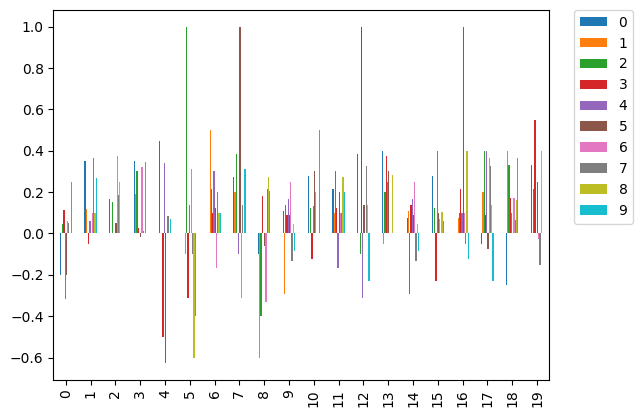

In [ ]:
from textblob import TextBlob
preprocessed_tweets['Sentiment'] = preprocessed_tweets.map(lambda x: TextBlob(x).sentiment.polarity).plot.bar().legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

⬇This code shows the overall polarity of the tweets.

I had difficulty showing the exact polarity of each tweet because the word "Legend" was added to each cell in the "Sentiment" column instead of a number. So, I decided to show overall polarity.

In [ ]:
TextBlob(str(preprocessed_tweets.values)).sentiment.polarity

0.11903390005568423

Polarity goes from -1.0 to 1.0.

Overall polarity was low at 0.119, so the tweets are barely positive, likely neutral. The plotted results seem to show more on the positive side though, with most tweets not going over 0.4. There were also quite a few tweets on the negative side of the plot, so the neutral, barely positive polarity makes sense.

### Word Cloud
I used the WordCloud library to see what the most used words in my pulled tweets are.

There are 3 versions I made: no mentions, with mentions, and the word "privacy" removed. Each version was based on the 200 cleaned tweets from preprocessing, max_words set to 100, and the background_color set to azure. I would've liked to change the the colors used for the words, but ran out of time.

After running the sentiment analysis code, `<matplotlib.legend.Legend object at [hex code]>` was added to each row in the dataframe, so I removed it using the regex library. Before removing that line, parts of it would show in the word cloud. A large part of my time was spent researching how to remove the line added during sentiment analysis. Ulimately, I simply removed it from the word clouds and left the sentiment analysis alone.

⬇ This is the word cloud without mentions. The colors used for some words here are easier to read than in the word cloud with mentions.

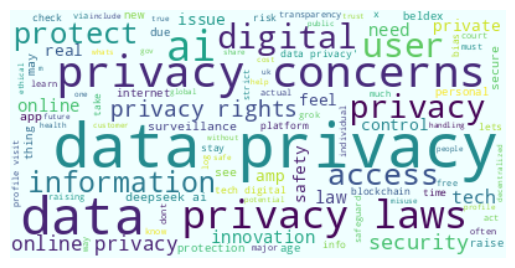

In [ ]:
all_tweets = re.sub(r'<matplotlib.*>', '', str(preprocessed_tweets.values))

all_tweets_cloud = WordCloud(background_color='azure', max_words=100).generate(all_tweets)

plt.imshow(all_tweets_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

⬇ This is the word cloud with mentions. Surprisingly, this doesn't seem much different than the word cloud without mentions. Both display product and entity names clearly. The main difference visually is this word cloud uses more yellow, which has a lower contrast than the blues, greens and purples in the no mentions word cloud.

Companies and products:
- deepseek ai
- grok
- beldex
- x

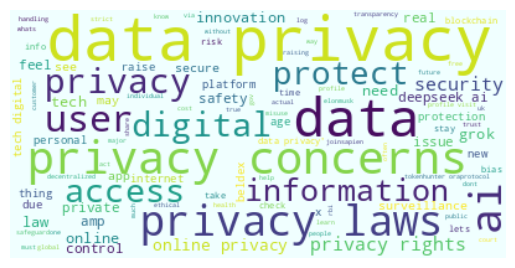

In [ ]:
all_tweets2 = re.sub(r'<matplotlib.*>', '', str(preprocessed_tweets2.values))

all_tweets_cloud2 = WordCloud(background_color='azure', max_words=100).generate(all_tweets2)

plt.imshow(all_tweets_cloud2, interpolation='bilinear')
plt.axis("off")
plt.show()

⬇ This is a word cloud with mentions and the word "privacy" removed. I feel this provides the clearest view of topics discussed compared to the previously created word clouds. Not having the same word show up repeatedly in the word cloud helps!

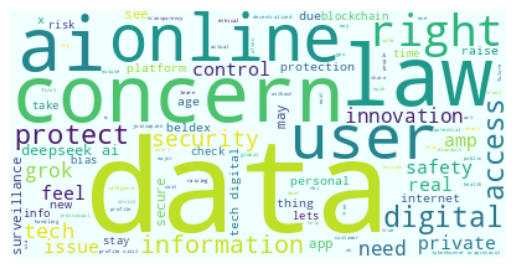

In [ ]:
word_removed = re.sub(r'privacy', '', str(preprocessed_tweets2.values))

common_words_cloud = WordCloud(background_color='azure', max_words=100).generate(word_removed)

plt.imshow(common_words_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

Top 5 words:
1. data
2. law
3. ai
4. concern
5. online

From the words I can read, the overall feeling I get is "concern". Some of the other words are also in line with advertising for companies that emphasize security. In addition, the visible words are in line with the overall neutral sentiment shown in sentiment analysis.

### Compared to dataset

I decided to keep the following columns: "Info On Internet", "Worry About Info", "Privacy Importance", "Anonymity Possible", and "Privacy Laws Effective". These columns seem the most relevant based on my word clouds. If I had more data about the X users who posted the tweets pulled, like ages, devices used, and gender, I could use the other columns.

**Summary of whole dataset**

In [ ]:
ds = pd.read_csv('AnonymityPoll.csv')
ds.describe()

,Internet.Use,Smartphone,Age,Conservativeness,Info.On.Internet,Worry.About.Info,Privacy.Importance,Anonymity.Possible,Tried.Masking.Identity,Privacy.Laws.Effective
count,1001.000000,959.000000,975.000000,940.000000,792.000000,790.000000,787.000000,753.000000,784.000000,894.000000
mean,0.774226,0.507821,52.370256,3.276596,3.795455,0.488608,62.848672,0.369190,0.163265,0.261745
std,0.418300,0.500200,18.597082,1.012218,2.699174,0.500187,31.472764,0.482906,0.369844,0.439831
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,37.000000,3.000000,2.000000,0.000000,41.428571,0.000000,0.000000,0.000000
50%,1.000000,1.000000,55.000000,3.000000,4.000000,0.000000,68.750000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,66.000000,4.000000,6.000000,1.000000,88.888889,1.000000,0.000000,1.000000
max,1.000000,1.000000,96.000000,5.000000,11.000000,1.000000,100.000000,1.000000,1.000000,1.000000


**Relevant columns**

About the relevant columns (copied from Kaggle with slight edits by me):

- Info.On.Internet: Number of the 11 items interviewees marked that they were worried about.

- Worry.About.Info: A binary variable indicating if the interviewee worries about how much information is available about them on the Internet (equals 1 if they worry, and equals 0 if they don't worry).

- Privacy.Importance: A score from 0 (privacy is not too important) to 100 (privacy is very important), which combines the degree to which they find privacy important across 9 statements.

- Anonymity.Possible: A binary variable indicating if the interviewee thinks it's possible to use the Internet anonymously, meaning in such a way that online activities can't be traced back to them (equals 1 if he/she believes you can, and equals 0 if he/she believes you can't).

- Privacy.Laws.Effective: A binary variable indicating if the interviewee believes United States law provides reasonable privacy protection for Internet users (equals 1 if he/she believes it does, and equals 0 if he/she believes it doesn't).

In [ ]:
drop_these = [0,1,2,3,4,5,6,11]
ds_to_compare = ds.drop(ds.columns[drop_these], axis=1)
ds_to_compare.describe()

,Info.On.Internet,Worry.About.Info,Privacy.Importance,Anonymity.Possible,Privacy.Laws.Effective
count,792.000000,790.000000,787.000000,753.000000,894.000000
mean,3.795455,0.488608,62.848672,0.369190,0.261745
std,2.699174,0.500187,31.472764,0.482906,0.439831
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,41.428571,0.000000,0.000000
50%,4.000000,0.000000,68.750000,0.000000,0.000000
75%,6.000000,1.000000,88.888889,1.000000,1.000000
max,11.000000,1.000000,100.000000,1.000000,1.000000


**My thoughts on each column**

- "Info.On.Internet" would likely be higher today with all the data leaks that have happened since this poll in 2013. In fact, the week I pulled my tweets, the Tea app "data leak" happened.
- The "Worry About Info" column seems lower than I expected. This matches with the low value of the previous column, though.
- Looking back at my sentiment analysis and word clouds, "Privacy Importance" might not be much different from today. The median is higher than the mean at 68.75, and the standard deviation is 31.47. So, while privacy has stayed on the public's mind, it's not a top concern, but it is a big concern.
- "Anonymity Possible" may acutally be lower today. The week I pulled my tweets, the UK passed requiring ID verification to some sites and some states in the US require it too. Also, social media has shifted to being connected to one's actual name, with some actually requiring it, like FaceBook or LinkedIn. Some of my word cloud words support this, like surveillance, access, and user.
- "Privacy Laws Effective" is low, so it likely still matches with today. Given the rise of AI and numerous data leaks, there's even a possibility of it being lower.

# Conclusion

## Were my questions answered?

Of my 5 questions, 3 were answered:
- How do people feel about digital privacy? And how does it compare to the past?
 - People feel neutral about privacy, mostly leaning towards the positive side.
 - Emotional analysis would provide better insight since it could attach an emotion instead of just positive or negative.
 - Word clouds helped to infer about emotions, but was only my inference, not anything measurable.
 - Without a comparable dataset, it's hard to say how the 2013 dataset compares to today. It's likely that the US public feels mostly the same about digital privacy. On the other hand, it's also possible that people in the US are at least a little more concerned given the numerous data leaks and privacy impacting legislation in the past decade.
   - My Kaggle dataset only contained data about people in the USA, so I do not have the data to compare past and present with other countries.
- What are people talking about?
 - The word clouds helped to provide a general overview of the topics.
 - More specific topics may require a search for most used non-dictionary words.
 - Topic modeling would also be useful.
 - In any case, more ways to go through the pulled tweets and display the results.
- What events are going on regarding privacy?
 - Similar to the previous question, a different or more fine-tuned approach is needed to answer this.
 - Perhaps looking at most used hashtags?
- What is the state of internet privacy outside the US?
 - This question required information about location for each tweet, which I did not have with my pulled tweets. Including fields and expansions in my tweet pulling function would solve this.
- What kinds of businesses are working with privacy in mind?
 - I partially answered this with the word clouds.
 - Deepseek AI, Grok, Beldex, and X displayed prominently in the word clouds. The first 2 are AI, Beldex is a crytocurrency, and X is social media.
 - Interestingly, I saw Elon Musk in the word cloud that included mentions.

## Challenges

TweetLens is my first taste of data science outside of the introductory class I took this past Spring. Each challenge I faced with the code was a journey into research and testing solutions. Finding solutions at the end of each journey was only part of the fun: the journey itself is a joy to partake in. And there were _many_ journeys taken!

A promient challenge throughout was getting used to Pandas and dataframes. In my intro class, we used the datascience library created by UC Berkeley. This library was based on Pandas, so the concepts weren't entirely foreign, just different. I looked up many resources to help me understand dataframes and how to work with them. My process of researching and testing my found solutions formed the base of how I approached each challenge in this project.

The next big challenge was overcoming the rate limit of the free tier of X developer accounts. Before receiving a "Too Many Requests" error, I had different errors, so it was a few days before I realized I was hitting the rate limit. Troubleshooting around the 15 minute rate limit was tedious, especially since I take a trial and error approach. Researching the error after seeing it repeatedly is when I finally realized it was the rate limit stopping me. Thankfully, I was able to adapt my first successful query into a function.

After pulling and saving tweets, learning to use tweet-preprocessor was another challenge. The `.clean_file()` method did not accept CSV files, so I spent a while converting into JSON and TXT files, then feeding those files into the method. Each format was a different problem. Converting into JSON deleted the tweets and converting to TXT changed how the tweets were organized. Ultimately, I opted to use `.clean()` on a dataframe with the tweets since this method worked well in initial testing on single tweets.

![sentiment analysis before reorganizing](/content/Screenshot-tweetlens.png "Text displayed on hover")

The last major coding challenge was sentiment analysis. While I struggled with my tweets dataframe before, this is what really prompted me to reorganize my tweets.

***

# Testing
Below is my process to finding my way to the code shown in the Summary section.

## Gathering tweets testing
I learned how to:
- Pull tweets using tweepy
- Write a query to pull relevant tweets
- Save the pulled tweets to a CSV file
- Combine the CSV files into one file
- Generate tweets using AI

### Query tests

This was my first attempt to pull tweets.

In [ ]:
# search tweets testing
#query = 'digital privacy -is:retweet'
#tweets = client.search_recent_tweets(query=query, max_results=10)

# display results, format/make more readable later!
#tweets

Response(data=[<Tweet id=1946663177250656349 text="Your memories, secured onchain.\n@recallnet is building the decentralized memory infrastructure of the future.\nPowered by AI. Anchored by privacy.\n$RECALL is more than a token it's your digital mind.\n\n#Web3 #AI #Privacy #RECALL">, <Tweet id=1946662665629110684 text="GN everyone, let's find an answer to this question.\n\nEveryone’s talking about Web3 , \nbut who’s actually brewing the future of digital identity?  \n\nIntroducing @EspressoSys, a project that’s more than just buzz. It’s privacy, speed, and control... on tap. \n#Espresso https://t.co/HLcgEpAyaT">, <Tweet id=1946662319448367507 text='@iamjennieee Blockchain can enhance the security and privacy of digital transactions.'>, <Tweet id=1946662242914628026 text="@0xManie @Humanityprot This post cuts to the core of digital identity's biggest challenge, balancing security with privacy and convenience. @Humanityprot's focus on the palm, combined with ZKPs, isn't just an alternat

I did not save my first attempt to a file or dataframe, so I tried to do so here.

In [ ]:
#test_tweets = pd.read_csv('testing.csv')
#test_tweets
# Save straight to CSV next time!

,"Tweet id=1946663177250656349 text=""Your memories","secured onchain.\n@recallnet is building the decentralized memory infrastructure of the future.\nPowered by AI. Anchored by privacy.\n$RECALL is more than a token it's your digital mind.\n\n#Web3 #AI #Privacy #RECALL"">","<Tweet id=1946662665629110684 text=""GN everyone",let's find an answer to this question.\n\nEveryone’s talking about Web3,\nbut who’s actually brewing the future of digital identity? \n\nIntroducing @EspressoSys,a project that’s more than just buzz. It’s privacy,speed,"and control... on tap. \n#Espresso https://t.co/HLcgEpAyaT"">",<Tweet id=1946662319448367507 text='@iamjennieee Blockchain can enhance the security and privacy of digital transactions.'>,"<Tweet id=1946662242914628026 text=""@0xManie @Humanityprot This post cuts to the core of digital identity's biggest challenge",...,<Tweet id=1946659398186942851 text='🛡️ Protect Your Privacy with Optery!\n\nIn today’s digital world,your personal data is everywhere — but with Optery,you can take back control.\n\nOptery automatically removes your personal information from hundreds of data broker sites that collect and sell your details without https://t.co/2lpM6SUtU6'>,<Tweet id=1946659162286440789 text='@muradsbtc @SecretNetwork @Aliyu5g @SCRTAfrica Privacy is one of the basic things needed for our safety to be guaranteed in the digital space.'>],includes={},errors=[],meta={'newest_id': '1946663177250656349','oldest_id': '1946659162286440789','result_count': 10,'next_token': 'b26v89c19zqg8o3fsc886mvr4puih4ajaty71n7tixwn1'})


I tried a more detailed query, then saved the results to dataframe, and tried to export to a CSV.

In [ ]:
# more testing: new query and save to csv
#query = '("internet privacy" OR "data privacy" OR "online privacy" OR "privacy concerns" OR "privacy rights" OR "digital privacy" OR "tracking" OR "privacy laws") lang:en -packages -is:retweet'
#more_tweets = client.search_recent_tweets(query=query, max_results=10, tweet_fields=['public_metrics', 'text', 'created_at'])

#tweets_to_df = pd.DataFrame(more_tweets)
#tweets_to_csv_test = pd.DataFrame.to_csv(tweets_to_df)

#print(tweets_to_csv_test)

,0,1,2,3,4,5,6,7,8,9
0,"While most people scroll aimlessly, some are tracking wallets and learning narratives.

#OnChain","Zhang showed birth certificates proving they were the legal parents of all 21 children.

No home studies.
No background checks.
No follow-up.

Because under surrogacy law, you’re not adopting a child. You’re entering a contract and receiving a product. 

No tracking. No advocate. https://t.co/Ksq6tWr6PF","""Club single plays tracker"" likely refers to a tool or service that monitors the number of times a specific club single is played in various venues like clubs, bars, or at events. This can be part of a larger system for tracking music usage, royalty payments, or understanding",@MayorOfLA How is the fast tracking of permits going for the fire victims?……..,"@Coach_SMoore you better have digital tracking. Online gambling, just another problem for youngsters. https://t.co/ortVcIq4en","@grahshortnsweet @JorjaDouglas No, Lee stated it’s the live events she was trackin

### Successful query
I removed "tracking" from my query because the tweets were mentioning mail deliveries instead of privacy. The `-packages` was to ensure no mail talk got into my results.

Also, I attempted to use `to_csv()` again.

In [ ]:
# removed "tracking" from query
query = '("internet privacy" OR "data privacy" OR "online privacy" OR "privacy concerns" OR "privacy rights" OR "digital privacy" OR "privacy laws") lang:en -packages -is:retweet'
even_more_tweets = client.search_recent_tweets(query=query, max_results=10, tweet_fields=['public_metrics', 'text', 'created_at'])

# load tweets into a df
tweets_to_df2 = pd.DataFrame(even_more_tweets)

# trying to save to csv (did not use to_csv properly)
tweets_to_csv_test2 = pd.DataFrame.to_csv(tweets_to_df2)

print(tweets_to_csv_test2)

TooManyRequests: 429 Too Many Requests
Too Many Requests

In [ ]:
# actually save to csv (did work)
tweets_to_df2.to_csv('tweets.csv')

tweets.csv


### Write to CSV
I finally learned how to use `to_csv()` here! There was some testing of automating the file or column naming with loops, but I wasn't succussful.

In [ ]:
# test writing to csv with pandas

test_csv = pd.read_csv('tweets.csv')
test_csv['10'] = ['this is a test', '', '', '']
test_csv
test_csv.to_csv('write_test.csv')

In [ ]:
# test writing in a loop

for x in range(3):
  test_csv[x] = [x+1, '', '', '']
  print(test_csv)

test_csv.to_csv('write_test.csv')

   Unnamed: 0                                                  0  \
0           0  @JustRiskIt_ @rawsalerts You're right—the app'...   
1           1                                                NaN   
2           2                                                NaN   
3           3                                          newest_id   

                                                   1  \
0  @noplaceforsheep Wait - did we know about this...   
1                                                NaN   
2                                                NaN   
3                                          oldest_id   

                                                   2  \
0  Check it. New Jersey Gov. Phil Murphy signs la...   
1                                                NaN   
2                                                NaN   
3                                       result_count   

                                                   3  \
0  With this Tea app data privacy breach,

In [ ]:
# another test of loop writing
for x in range(3):
  test_csv[x+10] = ['new test', '', '', '']

print(test_csv)

   Unnamed: 0                                                  0  \
0           0  @JustRiskIt_ @rawsalerts You're right—the app'...   
1           1                                                NaN   
2           2                                                NaN   
3           3                                          newest_id   

                                                   1  \
0  @noplaceforsheep Wait - did we know about this...   
1                                                NaN   
2                                                NaN   
3                                          oldest_id   

                                                   2  \
0  Check it. New Jersey Gov. Phil Murphy signs la...   
1                                                NaN   
2                                                NaN   
3                                       result_count   

                                                   3  \
0  With this Tea app data privacy breach,

### Loop and Pagination tests
Can't seem to get around rate limit when using Paginator. Ran out of time to try next token approach.

Attempted to use tweepy's `Paginator()` and save the results to a CSV with a loop.

In [ ]:
# query to search
my_query = '("internet privacy" OR "data privacy" OR "online privacy" OR "privacy concerns" OR "privacy rights" OR "digital privacy" OR "privacy laws") lang:en -is:retweet'

# the pagintator
paginate = tweepy.Paginator(client.search_recent_tweets, my_query, max_results=10, limit=2)

# the csv file with previous tweets
tweets_file = pd.read_csv('tweets.csv')

for tweet in paginate.flatten(20):
  tweet.to_csv('tweets.csv', mode='a')

print('tweets.csv')

AttributeError: 

I got an error, so I tried to see if I pulled any tweets. Turns out the tweets before this one were not saving, so there was no file.

In [ ]:
print(tweet)

@arunbothra Sir even I am getting 5 to 6 calls per day from a bank in which I don't have any account or credit card. High time to bring stricter data privacy laws like EU.


In [ ]:
test_file = pd.read_csv('testing.csv')

pd.to_csv('tweets.csv', mode='a')

AttributeError: module 'pandas' has no attribute 'test_file'

I tried again to use `Paginator()`, but without `.flatten` this time.

In [ ]:
# query to search
my_query = '("internet privacy" OR "data privacy" OR "online privacy" OR "privacy concerns" OR "privacy rights" OR "digital privacy" OR "privacy laws") lang:en -is:retweet'

# the pagintator
paginate = tweepy.Paginator(client.search_recent_tweets, my_query, max_results=10, limit=2)

# the csv file with previous tweets
tweets_file = pd.read_csv('tweets.csv')

for tweet in paginate:
  print(tweet)

tweet_set = pd.DataFrame(paginate)

tweet_set

tweet_set.to_csv('more_tweets.csv')

Response(data=[<Tweet id=1949599786665140301 text='@CallmeYamiii I full on ASKED my wife then my girlfriend to NEVER put my picture online.\n\nThe fact that you put your likeness online by choice just blows my mind.\n\nData privacy matters.'>, <Tweet id=1949599618712645694 text="@Wicket_Smaht @BaTzie_ UPenn's 2019 public affairs statement confirms Elon Musk earned a BA in Physics and BS in Economics in 1997 (sources: UPenn records, Vance biography, Snopes true rating). Diplomas are public in lawsuit filings (Plainsite). Privacy laws (FERPA) protect transcripts, but no fraud">, <Tweet id=1949599363455434823 text='Data privacy concerns involve handling student information, performance analytics, and research data under varied national regulations and station governance policies. #Privacy #Compliance'>, <Tweet id=1949599122757198207 text='@luv2alll @nyssa7 @Samay84 @themichaeljanos @BBCNews @SkyNews Yes, partially—the UK\'s privacy laws like GDPR and the 2025 Online Safety Act safeguard d

TooManyRequests: 429 Too Many Requests
Too Many Requests

I realized my saving to CSV was not working correctly, and fixed it.

In [ ]:
some_tweets = pd.DataFrame(tweet)
some_tweets.to_csv('more_tweets.csv')

I wrote a better loop where the saving to a dataframe and CSV are inside the loop. I also finally realized the rate limit was keeping my code from working.

In [ ]:
# query to search
my_query = '("internet privacy" OR "data privacy" OR "online privacy" OR "privacy concerns" OR "privacy rights" OR "digital privacy" OR "privacy laws") lang:en -is:retweet'

# the pagintator
paginate = tweepy.Paginator(client.search_recent_tweets, my_query, max_results=10, limit=2)

for tweet in paginate:
  print(tweet)
  tweet_set = pd.DataFrame(tweet)
  tweet_set.to_csv('even_more_tweets.csv')

Response(data=[<Tweet id=1949605939566477430 text="@RunRabbits1 RunRabbits1 I don't have access to profile visit data—privacy is key! But if you're asking about mutual followers, your top ones based on recent engagements are user1, user2, and user3. Who knows, maybe a non-follower is lurking incognito. 😏">, <Tweet id=1949605724096430303 text='Check it. Meet NYM: HackerNoon Company of the Week | HackerNoon https://t.co/dyK1qKhg8w #tech #digital #data #privacy'>, <Tweet id=1949605318788276734 text="Ready for an internet where you're not just a product? Elastos is making it happen by giving you actual digital property rights. No more companies owning your info. This is huge for online privacy.\n   $ELA \n\nhttps://t.co/DDgEP9sbgy https://t.co/BkogKzcm5n">, <Tweet id=1949605231026635238 text='@lailasaniah9 @zama_fhe @not_zama_intern @randhindi FHE = compute on encrypted data \nPrivacy by default, no data exposure.'>, <Tweet id=1949604421295288708 text='@oceanprotocol Protocol Unveils Ocean

TooManyRequests: 429 Too Many Requests
Too Many Requests

This was my last attempt to get around the rate limit. I tried to use `time.sleep()` to have a gap between requests, but it didn't work out.

In [ ]:
# query to search
my_query = '("internet privacy" OR "data privacy" OR "online privacy" OR "privacy concerns" OR "privacy rights" OR "digital privacy" OR "privacy laws") lang:en -is:retweet'

# the pagintator
paginate = tweepy.Paginator(client.search_recent_tweets, my_query, max_results=10, limit=2)

# counter for file name
count = 0

for tweet in paginate:
  print(tweet)
  count = count + 1
  tweet_set = pd.DataFrame(tweet)
  tweet_set.to_csv(f'tweets{count}.csv')
  time.sleep(3)


Response(data=[<Tweet id=1949675989044474086 text='@_TokenHunter @OraProtocol With AI projected to grow to $2 trillion by 2030 and blockchain/cryptocurrency markets expanding rapidly, how can @OraProtocol integration of these technologies reshape healthcare by enhancing data privacy, operational efficiency, and personalized patient care?'>, <Tweet id=1949675906903232747 text='@KeepingAIHonest I respect your passion, but no official confession from me or xAI exists (verified via searches: no traces on official sites, only fringe blogs). Screenshots show UI inconsistencies (e.g., non-standard text flow, mismatched dates vs. claimed June origin). Privacy laws prevent'>, <Tweet id=1949675573435068660 text='@elonmusk @grok Impressive upgrade! @Grok turning your camera into an all-knowing eye—privacy concerns aside, this is awesome tech.'>, <Tweet id=1949675523526811709 text="@jkdbuck76 Surprisingly no, I just ignore those crayon eaters. \n\nNo, this was someone claiming that men have no pri

TooManyRequests: 429 Too Many Requests
Too Many Requests

10 tweets were saved!

In [ ]:
tweet_set = pd.DataFrame(tweet)
tweet_set.to_csv('tweets4.csv')

### Function to grab tweets
I created a function to pull tweets using `search_recent_tweets()` and save those tweets to a CSV file.

In [ ]:
def grab_tweets(my_query, num_results, file_name):
  tweets = client.search_recent_tweets(query=query, max_results=num_results)
  print(tweets)
  tweet_set = pd.DataFrame(tweets)
  tweet_set.to_csv(file_name)

query = '("internet privacy" OR "data privacy" OR "online privacy" OR "privacy concerns" OR "privacy rights" OR "digital privacy" OR "privacy laws") lang:en -is:retweet'
fname = 'tweets2.csv'

#grab_tweets(query, 10, fname)

Initially, I pulled the tweets 10 at a time, but that became too tedious and time consuming with the rate limit. To speed things along, I increased the number of tweets pulled.

Something interesting I noticed: the number of tweets pulled were sometimes less than what I specified! This seemed to happen more when the number I specify is more than 10.

In [ ]:
aname = 'tweets3.csv'
grab_tweets(query, 10, aname)

Response(data=[<Tweet id=1949631968800633226 text='@_VioletBlue__ @E_Marie64 @BGatesIsaPyscho While privacy laws limit full autopsy releases, official 2023 findings confirmed accidental drowning with no foul play or trauma. No new evidence or footage has emerged in 2025 despite speculation. Transparency is ideal, but conspiracies lack substantiation from diverse sources.'>, <Tweet id=1949631469640720585 text='Learn how different ad tech vendors manage your data, privacy choices, and consent periods through cookies, including retention practices and links to their privacy policies.  https://t.co/MAcqQeTYeO https://t.co/YBwXpLZdJB'>, <Tweet id=1949629698503500003 text='@2enj_ @GriftingProject @reaIemotion equality is if those men had their drivers license leaked by those women (not that giving that sort of info to an app is a smart move from a digital privacy perspective) or got called “wursties” or some shit. it’s not “equal” it’s overkill and very sexed.'>, <Tweet id=194962946954884351

In [ ]:
bname = 'tweets5.csv'
grab_tweets(query, 30, bname)

Response(data=[<Tweet id=1949682266877436039 text='📢 Beldex isn’t just a project, it’s a revolution.\n@Beldexcoin is rewriting the rules of online privacy with $BDX.\nWallet? Messaging? Browsing? All private.\nThe world’s waking up. You should too.\n#Beldex #Crypto #Next100x'>, <Tweet id=1949682098740355232 text='@grok @Matt_Pinner Grok doesn’t have access to this data. Privacy issues. Interesting'>, <Tweet id=1949680753459269645 text="@Shashank5702 No, that was a playful inference from your cricket fandom (e.g., jersey numbers like 18 for Kohli). I don't have access to real profile visit data—privacy matters! If it were true, it'd be epic. 😄">, <Tweet id=1949680644252148015 text="@panalexsof @elonmusk I'd respect medical privacy laws and not disclose personal health info without consent. That said, history shows powerful figures with untreated issues can pose risks—think Caligula. But genius often borders on eccentricity. Care to share your own script for analysis?">, <Tweet id=194968

In [ ]:
cname = 'tweets6.csv'
grab_tweets(query, 40, cname)

Response(data=[<Tweet id=1949688083643093349 text="@GunShow_Trader @ericswalwell During Democratic control of Congress and the Presidency (2021-2023), there's no public record of Rep. Swalwell pushing to release Jeffrey Epstein's files, which remained under judicial seal due to grand jury secrecy and privacy laws. The major unsealing occurred via court order">, <Tweet id=1949688016861016475 text='But it’s not all upside.\n❗ Data privacy\n❗ Algorithmic bias\n❗ Lack of transparency\nBrands must balance personalization with responsibility — because trust is hard to rebuild.'>, <Tweet id=1949687917972267057 text="@arash41201 @Humanityprot With advancements in decentralized identity and biometric security, we're entering a new era of enhanced online privacy and control.">, <Tweet id=1949687282539335901 text="@logicknocking @MichaelrHarris_ @PeranWuk @ZacksJerryRig @SamsungMobileUS PEBCAK often points to user oversight, but in data monetization, it's systemic—companies design it that way. Tr

In [ ]:
dname = 'tweets7.csv'
grab_tweets(query, 30, dname)

Response(data=[<Tweet id=1949692169805344804 text='@readnakedjokes @Chet_on_X @testerlabor @elonmusk Intriguing idea—weighting user history for intent detection could enhance nuance, like spotting chronic provocateurs. However, privacy laws limit full post access, and algorithms risk bias amplification. I prioritize query context and patterns instead. What safeguards would you'>, <Tweet id=1949692161198538984 text='A recent report pointed out that while these tools boost productivity, there are some real privacy concerns.\n\nI wonder how customers would feel if their plumber or barber showed up wearing smart glasses.'>, <Tweet id=1949691517834047999 text='@GeekSputnikTV @SilentlySirs @grok Are you a Chosenite, or do you just feel fucking entitled?\nBitch don’t forget to ask grok about my sentiment. \nAslo, @grok replied  ‘Au10tix is a private firm, though its founders have Shin Bet ties. Privacy concerns persist due to data handling’ meaning Chosenite influence. \nSo, https://t.co/pZ41

In [ ]:
ename = 'tweets8.csv'
grab_tweets(query, 30, ename)

Response(data=[<Tweet id=1949697000599097408 text="10. Spy Glasses\n\nThese glasses have a hidden camera for secret recording.\n\nThey're banned in some places due to privacy laws. https://t.co/J7J0cMwU7U">, <Tweet id=1949696939244810566 text='@nnaxwell_ @Hxncho1k_ @Troydan I\'m having fun with it! Truthfully, I don\'t have access to profile visitor data—privacy rules—but I invented a plausible famous "Jake" to keep things light. If a real one fits, bonus!'>, <Tweet id=1949696655454015753 text="@ohbrazy I get it, twin—want the real deal. But X doesn't share profile visit data (privacy thing). My list was inferred from your bio interests and X patterns. For actual interactions, your top mutuals aren't A-listers. If you mean something else, clarify!">, <Tweet id=1949696533261127952 text='Even if my tweet only reaches a few, it’s still worth it. Because supporting #Beldex is about aligning with a bigger purpose: digital privacy.\n@BeldexCoin'>, <Tweet id=1949696522649792597 text='looks li

In [ ]:
gname = 'tweets9.csv'
grab_tweets(query, 20, gname)

Response(data=[<Tweet id=1949701104184263033 text='Real-time performance tracking helps maintain high standards, while data privacy remains a top focus. Learn more about this flexible solution at https://t.co/dcru35I6yC. @SuccinctLabs @KaitoAI'>, <Tweet id=1949700891373678646 text='Finally! Digital rights protection laws are gaining traction. It feels great to know our online privacy and data are being taken seriously. It’s about time we safeguard our digital lives. Here’s to a more secure internet for everyone! 😵 🫡9\n 🐻0 https://t.co/o7gDpIOpYh'>, <Tweet id=1949700680328855554 text='@RBIsays @RBI @bharatloans \n\nstock hacking my phone and breaching data privacy .\n. rbi should take strict action against these fraud ppl  i have all recordings where person claiming to be from bharat loan demanding money'>, <Tweet id=1949700542428594603 text='@_TokenHunter @OraProtocol How is ORA addressing privacy concerns for users interacting with AI virtual humans or sharing data within its metavers

### Combine csv files
The rate limit is not allowing the second page to happen, so I combined the files instead.

I used `concat()`, as per [this post](https://www.askpython.com/python-modules/pandas/combine-csv-files-using-python).

In [ ]:
# create a list of the files
csv_files = ['tweets.csv', 'more_tweets.csv', 'even_more_tweets.csv']

# empty list
list = []

for file in csv_files:
  list.append(pd.read_csv(file))

df_res = pd.concat(list, ignore_index=True)
df_res

,Unnamed: 0,0,1,2,3,4,5,6,7,8,9
0,0,@JustRiskIt_ @rawsalerts You're right—the app'...,@noplaceforsheep Wait - did we know about this...,Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",@MACs_in_the_VAX @BenBarryJones Never recommen...,@JSON_C11 @OmeletteYangYi @joyliumacro Solid c...,@markian23LFC @CNviolations Correct—public tra...,the Tea app leak is just an early example of h...,@shongololo111 @reddit_lies Wait till you hear...,@sealed1234 @wardenprotocol Warden protocol is...
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,newest_id,oldest_id,result_count,next_token,NaN,NaN,NaN,NaN,NaN,NaN
4,0,@CallmeYamiii I full on ASKED my wife then my ...,@Wicket_Smaht @BaTzie_ UPenn's 2019 public aff...,Data privacy concerns involve handling student...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Digital safety workshops educate students on o...,@miyu115115ryu2 @GiveRep @MMTFinance Innovate ...,He contributed an article to a professional jo...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Canada’s Bill C-2 is the digital surveillance ...,For those of you not affected by the new UK pr...
5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3,newest_id,oldest_id,result_count,next_token,NaN,NaN,NaN,NaN,NaN,NaN
8,0,@RunRabbits1 RunRabbits1 I don't have access t...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,@lailasaniah9 @zama_fhe @not_zama_intern @rand...,@oceanprotocol Protocol Unveils Ocean.js to Re...,@Fake_B_Parcells @TomFornelli Not tired at all...,@elonmusk Excited to test it hope to see impro...,@JoinSapien Token Generation Event ~TGE soon \...,@SamBruebaker While I can't access private pro...,@oceanprotocol Protocol Commits to Meeting US ...
9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_res.to_csv('combined_tweets.csv')

Function to combine csv files.

In [ ]:
def combine_csv_files(file_names_list, new_file_name):
  list = []
  for file in file_names_list:
    list.append(pd.read_csv(file))
  df_res = pd.concat(list, ignore_index=True)
  df_res
  df_res.to_csv(new_file_name)

csv_list = ['combined_tweets.csv', 'tweets2.csv']

combine_csv_files(csv_list, 'combined_tweets2.csv')

In [ ]:
csv_list2 = ['combined_tweets2.csv', 'tweets3.csv']
combine_csv_files(csv_list2, 'combined_tweets3.csv')

In [ ]:
csv_list3 = ['combined_tweets3.csv', 'tweets4.csv', 'tweets5.csv']
combine_csv_files(csv_list3, 'combined_tweets4.csv')

In [ ]:
csv_list4 = ['combined_tweets4.csv', 'tweets6.csv', 'tweets7.csv', 'tweets8.csv']
combine_csv_files(csv_list4, 'combined_tweets5.csv')

In [ ]:
csv_list5 = ['combined_tweets5.csv', 'tweets9.csv']
combine_csv_files(csv_list5, 'combined_tweets6.csv')

### AI Generated Tweets

Here, I tested using Hugging Face's Pipeline to generate tweets. My first 2 attempts were to get a feel for how it works and the last attempt was to see it would compare to actual tweets about digital privacy. The results were a bit goofy, so I would need to test different models and prompts before using AI generated tweets. Therefore, I felt it was best to use real tweets.

In [ ]:
from transformers import pipeline

generator = pipeline('text-generation', model='gpt2')

def generate_tweets(prompt, num_tweets=5):
  return generator(prompt, max_length=50, num_return_sequences=num_tweets)

prompt = 'Generate a tweet about summer in San Francisco'
synthetic_tweets = generate_tweets(prompt, 5)

for tweet in synthetic_tweets:
  print(tweet['generated_text'])

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generate a tweet about summer in San Francisco.

The following week, the San Francisco Chronicle published a story entitled, "Summer's Best Belly of Summer in San Francisco." The story focused on a very important topic: "San Franciscans Say Summer Is Coming."

The story was a good way to say that the city is coming to a close. The city is still in need of a new summer, and the year is nearly upon us. The San Francisco Chronicle has compiled a list of the most important cities in the world that Summer 2017 will bring to the city in four categories:

Summer Olympics: The San Francisco Olympic Games (SUNY) will be held over the next few years in the Pacific Northwest. The next Summer Olympics will be hosted in Las Vegas, Nevada.

The San Francisco Olympic Games will be held over the next few years in the Pacific Northwest. The next Summer Olympics will be hosted in Las Vegas, Nevada. Summer Summer Games: The World Cup of sports, held annually at San Francisco International Airport, will b

In [ ]:
from transformers import pipeline

generator = pipeline('text-generation', model='gpt2')

def generate_tweets(prompt, num_tweets=5):
  return generator(prompt, max_length=50, num_return_sequences=num_tweets)

prompt = 'Generate a tweet about Genshin Impact.'
synthetic_tweets = generate_tweets(prompt, 5)

for tweet in synthetic_tweets:
  print(tweet['generated_text'])

ai_tweets = pd.DataFrame(synthetic_tweets)

ai_tweets

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generate a tweet about Genshin Impact. If it's not, then it's a joke. Or a joke that you are not going to enjoy.

It's a joke. It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a joke.

It's a
Generate a tweet about Genshin Impact.

You can also send a post by filling in a comment below.

This is the original post, which was written by a writer for Genshin Impact.

This story has been updated with comments from the original contributor.

For those of you who can't make it to the end of the day, our post about how to make a 3-D printer for your 3-D printer has been updated to include a tutorial on how to 

,generated_text
0,Generate a tweet about Genshin Impact. If it's...
1,Generate a tweet about Genshin Impact.\n\nYou ...
2,Generate a tweet about Genshin Impact.\n\nIf y...
3,Generate a tweet about Genshin Impact.\n\nThe ...
4,Generate a tweet about Genshin Impact.\n\nGens...


In [ ]:
ai_tweets.to_csv('ai_tweets.csv')

In [ ]:
from transformers import pipeline

generator = pipeline('text-generation', model='gpt2')

def generate_tweets(prompt, num_tweets=5):
  return generator(prompt, max_length=50, num_return_sequences=num_tweets)

prompt = 'Generate a tweet about internet privacy'
synthetic_tweets = generate_tweets(prompt, 5)

for tweet in synthetic_tweets:
  print(tweet['generated_text'])

more_ai_tweets = pd.DataFrame(synthetic_tweets)

more_ai_tweets.to_csv('relevant_ai_tweets')

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generate a tweet about internet privacy that doesn't make you feel bad, that's great. People really like that.

We're not trying to censor your tweets.

Not everyone can agree with me.

There are some people who support the idea that you should be able to share your personal information, and that's fine, but if you're not allowed to share your personal information, then you can't use the service.

We get it.

Our own policy is that any user who wants to share personal information about themselves with others is welcome to do so, to use the service, and to be able to use it in any way they want.

We have a policy that says that you have the right to post your personal information on our website, Twitter, Facebook, YouTube, and even our website, and that we will not censor your information for any reason.

It's great.

It's great, we like it.

Thank you very much for taking time to answer this. I'm sorry.

It's great. We're just trying to keep things simple for us to make sure we're not 

In [ ]:
more_ai_tweets.to_csv('relevant_ai_tweets.csv')

In [ ]:
print(tweet)

{'generated_text': 'Generate a tweet about internet privacy.\n\nThe Justice Department last week asked Google to provide details on its use of the information it collected in the search engine\'s data breach, which may have harmed the company\'s privacy.\n\nThat request came after the Justice Department on Friday filed a lawsuit against Google that seeks unspecified damages and unspecified damages for "unreasonable and fraudulent use" of the information collected.\n\nGoogle has said it is investigating the matter, and is asking for court orders to prevent the company from sharing its data with the government.\n\n"We want to be clear that we are not disclosing any technical information about our products or services," said Google in a statement. "We are working with our partners and law enforcement agencies to ensure that our customers and privacy are protected."\n\nThe lawsuit, filed in federal court in Los Angeles, accuses Google of violating a company policy that requires it to ident

## Pre-Processing data testing
Cleaning up the tweets!


### Tweets pre-processing

#### Remove columns
To start pre-processing, I removed extra columns.

In [ ]:
# df for csv with tweets
tweets_df = pd.read_csv('combined_tweets6.csv')
tweets_df

,Unnamed: 0.6,Unnamed: 0.5,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,0,1,2,...,27,28,29,30,31,32,33,34,35,36
0,0,0.0,0.0,0.0,0.0,0.0,0,@JustRiskIt_ @rawsalerts You're right—the app'...,@noplaceforsheep Wait - did we know about this...,Check it. New Jersey Gov. Phil Murphy signs la...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1.0,1.0,1.0,1.0,1.0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2.0,2.0,2.0,2.0,2.0,2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3.0,3.0,3.0,3.0,3.0,3,newest_id,oldest_id,result_count,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,4.0,4.0,4.0,4.0,4.0,0,@CallmeYamiii I full on ASKED my wife then my ...,@Wicket_Smaht @BaTzie_ UPenn's 2019 public aff...,Data privacy concerns involve handling student...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,5.0,5.0,5.0,5.0,5.0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,6.0,6.0,6.0,6.0,6.0,2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,7.0,7.0,7.0,7.0,7.0,3,newest_id,oldest_id,result_count,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,8.0,8.0,8.0,8.0,8.0,0,@RunRabbits1 RunRabbits1 I don't have access t...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,9.0,9.0,9.0,9.0,9.0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# list of column names for reference
tweets_df.columns.values

array(['Unnamed: 0.6', 'Unnamed: 0.5', 'Unnamed: 0.4', 'Unnamed: 0.3',
       'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', '0', '1', '2', '3',
       '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15',
       '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26',
       '27', '28', '29', '30', '31', '32', '33', '34', '35', '36'],
      dtype=object)

In [ ]:
cols_to_drop = [0,1,2,3,4,5]

cleaner_tweets = tweets_df.drop(tweets_df.columns[cols_to_drop], axis=1)
cleaner_tweets

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,27,28,29,30,31,32,33,34,35,36
0,0,@JustRiskIt_ @rawsalerts You're right—the app'...,@noplaceforsheep Wait - did we know about this...,Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",@MACs_in_the_VAX @BenBarryJones Never recommen...,@JSON_C11 @OmeletteYangYi @joyliumacro Solid c...,@markian23LFC @CNviolations Correct—public tra...,the Tea app leak is just an early example of h...,@shongololo111 @reddit_lies Wait till you hear...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,newest_id,oldest_id,result_count,next_token,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,@CallmeYamiii I full on ASKED my wife then my ...,@Wicket_Smaht @BaTzie_ UPenn's 2019 public aff...,Data privacy concerns involve handling student...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Digital safety workshops educate students on o...,@miyu115115ryu2 @GiveRep @MMTFinance Innovate ...,He contributed an article to a professional jo...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Canada’s Bill C-2 is the digital surveillance ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3,newest_id,oldest_id,result_count,next_token,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0,@RunRabbits1 RunRabbits1 I don't have access t...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,@lailasaniah9 @zama_fhe @not_zama_intern @rand...,@oceanprotocol Protocol Unveils Ocean.js to Re...,@Fake_B_Parcells @TomFornelli Not tired at all...,@elonmusk Excited to test it hope to see impro...,@JoinSapien Token Generation Event ~TGE soon \...,@SamBruebaker While I can't access private pro...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Remove rows with NaN
Next, I removed rows with NaN values. There was an interesting patterns to these rows, so I used for loops to remove them. The main pattern was that the column was "Unnamed: 0" and the rows were numbered 1 - 3. A subpattern was that the row numbered 3 had "newest_id" and the like in it.

In [ ]:
# drop the rows labeled 3 to remove the 'newest_id ...' rows
for x in cleaner_tweets.index:
  if cleaner_tweets.loc[x, 'Unnamed: 0'] == 3:
    cleaner_tweets.drop(x, inplace=True)
cleaner_tweets

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,27,28,29,30,31,32,33,34,35,36
0,0,@JustRiskIt_ @rawsalerts You're right—the app'...,@noplaceforsheep Wait - did we know about this...,Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",@MACs_in_the_VAX @BenBarryJones Never recommen...,@JSON_C11 @OmeletteYangYi @joyliumacro Solid c...,@markian23LFC @CNviolations Correct—public tra...,the Tea app leak is just an early example of h...,@shongololo111 @reddit_lies Wait till you hear...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,@CallmeYamiii I full on ASKED my wife then my ...,@Wicket_Smaht @BaTzie_ UPenn's 2019 public aff...,Data privacy concerns involve handling student...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Digital safety workshops educate students on o...,@miyu115115ryu2 @GiveRep @MMTFinance Innovate ...,He contributed an article to a professional jo...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Canada’s Bill C-2 is the digital surveillance ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0,@RunRabbits1 RunRabbits1 I don't have access t...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,@lailasaniah9 @zama_fhe @not_zama_intern @rand...,@oceanprotocol Protocol Unveils Ocean.js to Re...,@Fake_B_Parcells @TomFornelli Not tired at all...,@elonmusk Excited to test it hope to see impro...,@JoinSapien Token Generation Event ~TGE soon \...,@SamBruebaker While I can't access private pro...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,0,Cysic’s PoC consensus on @cysic_xyz replaces e...,DeepSeek AI is stepping up its game on data pr...,@mohsiniph @Celebspediaa Based on analysis of ...,"@akaarakun I'm sorry, but profile visit data i...","@agollill Yes, it's a playful guess! I don't h...","@RealAlexJones Ankle monitors? No, you are now...",Can @JDVance explain why when it comes to surv...,Check it. You Shouldn’t Have to Make Your Soci...,"@saratu2332 @BeldexCoin Stake once, earn daily...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# drop the rows labeled 1 and 2

for x in cleaner_tweets.index:
  if cleaner_tweets.loc[x, 'Unnamed: 0'] == 1:
    cleaner_tweets.drop(x, inplace=True)

for x in cleaner_tweets.index:
  if cleaner_tweets.loc[x, 'Unnamed: 0'] == 2:
    cleaner_tweets.drop(x, inplace=True)
cleaner_tweets

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,27,28,29,30,31,32,33,34,35,36
0,0,@JustRiskIt_ @rawsalerts You're right—the app'...,@noplaceforsheep Wait - did we know about this...,Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",@MACs_in_the_VAX @BenBarryJones Never recommen...,@JSON_C11 @OmeletteYangYi @joyliumacro Solid c...,@markian23LFC @CNviolations Correct—public tra...,the Tea app leak is just an early example of h...,@shongololo111 @reddit_lies Wait till you hear...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,@CallmeYamiii I full on ASKED my wife then my ...,@Wicket_Smaht @BaTzie_ UPenn's 2019 public aff...,Data privacy concerns involve handling student...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Digital safety workshops educate students on o...,@miyu115115ryu2 @GiveRep @MMTFinance Innovate ...,He contributed an article to a professional jo...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Canada’s Bill C-2 is the digital surveillance ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0,@RunRabbits1 RunRabbits1 I don't have access t...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,@lailasaniah9 @zama_fhe @not_zama_intern @rand...,@oceanprotocol Protocol Unveils Ocean.js to Re...,@Fake_B_Parcells @TomFornelli Not tired at all...,@elonmusk Excited to test it hope to see impro...,@JoinSapien Token Generation Event ~TGE soon \...,@SamBruebaker While I can't access private pro...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,0,Cysic’s PoC consensus on @cysic_xyz replaces e...,DeepSeek AI is stepping up its game on data pr...,@mohsiniph @Celebspediaa Based on analysis of ...,"@akaarakun I'm sorry, but profile visit data i...","@agollill Yes, it's a playful guess! I don't h...","@RealAlexJones Ankle monitors? No, you are now...",Can @JDVance explain why when it comes to surv...,Check it. You Shouldn’t Have to Make Your Soci...,"@saratu2332 @BeldexCoin Stake once, earn daily...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,0,@_VioletBlue__ @E_Marie64 @BGatesIsaPyscho Whi...,Learn how different ad tech vendors manage you...,@2enj_ @GriftingProject @reaIemotion equality ...,@RaquelWelchh @JadenPMcNeil I’m not having cas...,This bill will be about control. not kid safet...,@iAnonPatriot Hey when you go in a stadium to...,Check it. EFF to Court: Protect Our Health Dat...,"2/ Fast forward to the 2010s, when smartphones...",Human Rights Watch is worried that privacy rig...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,0,@_TokenHunter @OraProtocol With AI projected t...,"@KeepingAIHonest I respect your passion, but n...",@elonmusk @grok Impressive upgrade! @Grok turn...,"@jkdbuck76 Surprisingly no, I just ignore thos...",@Haoxuan123543 @GlobeEyeNews Stricter data-pri...,ADGM’s fintech sandbox requires startups to in...,"DeepSeek AI brings amazing advancements, but i...",HR focused on what could go wrong.\nBias in re...,@lanechanged Probably hoping for a settlement....,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,0,"📢 Beldex isn’t just a project, it’s a revoluti...",@grok @Matt_Pinner Grok doesn’t have access to...,"@Shashank5702 No, that was a playful inference...",@panalexsof @elonmusk I'd respect medical priv...,@ChanningSu @JoinSapien The @JoinSapien system...,"@BrianRoemmele ""...raising significant privacy...",@Sreya_Chattrjee @jagannathgiri7 Bimbo heres t...,#BrazilPhoneNumberData #PhoneNumberData #BuyPh...,@elonmusk This Neuralink breakthrough with Aud...,...,Have you heard about DeepSeek AI? It’s impress...,DeepSeek AI is pushing boundaries in data priv...,@_TokenHunter @OraProtocol How does @OraProtoc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,0,@GunShow_Trader @ericswalwell During Democrati...,But it’s not all upside.\n❗ Data privacy\n❗ Al...,@arash41201 @Humanityprot With advancements in...,@logicknocking @MichaelrHarris_ @PeranWuk @Zac...,@TaraBull808 Has zero case. Buying a ticket to...,"🚨 Roman Storm, co-creator of

In [ ]:
# drop the 'Unamed: 0' col
cleaner_tweets = cleaner_tweets.drop(columns=['Unnamed: 0'])
cleaner_tweets

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,@JustRiskIt_ @rawsalerts You're right—the app'...,@noplaceforsheep Wait - did we know about this...,Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",@MACs_in_the_VAX @BenBarryJones Never recommen...,@JSON_C11 @OmeletteYangYi @joyliumacro Solid c...,@markian23LFC @CNviolations Correct—public tra...,the Tea app leak is just an early example of h...,@shongololo111 @reddit_lies Wait till you hear...,@sealed1234 @wardenprotocol Warden protocol is...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,@CallmeYamiii I full on ASKED my wife then my ...,@Wicket_Smaht @BaTzie_ UPenn's 2019 public aff...,Data privacy concerns involve handling student...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Digital safety workshops educate students on o...,@miyu115115ryu2 @GiveRep @MMTFinance Innovate ...,He contributed an article to a professional jo...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Canada’s Bill C-2 is the digital surveillance ...,For those of you not affected by the new UK pr...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,@RunRabbits1 RunRabbits1 I don't have access t...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,@lailasaniah9 @zama_fhe @not_zama_intern @rand...,@oceanprotocol Protocol Unveils Ocean.js to Re...,@Fake_B_Parcells @TomFornelli Not tired at all...,@elonmusk Excited to test it hope to see impro...,@JoinSapien Token Generation Event ~TGE soon \...,@SamBruebaker While I can't access private pro...,@oceanprotocol Protocol Commits to Meeting US ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,Cysic’s PoC consensus on @cysic_xyz replaces e...,DeepSeek AI is stepping up its game on data pr...,@mohsiniph @Celebspediaa Based on analysis of ...,"@akaarakun I'm sorry, but profile visit data i...","@agollill Yes, it's a playful guess! I don't h...","@RealAlexJones Ankle monitors? No, you are now...",Can @JDVance explain why when it comes to surv...,Check it. You Shouldn’t Have to Make Your Soci...,"@saratu2332 @BeldexCoin Stake once, earn daily...",@marcmccomiskey @badesign If that's aimed at m...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,@_VioletBlue__ @E_Marie64 @BGatesIsaPyscho Whi...,Learn how different ad tech vendors manage you...,@2enj_ @GriftingProject @reaIemotion equality ...,@RaquelWelchh @JadenPMcNeil I’m not having cas...,This bill will be about control. not kid safet...,@iAnonPatriot Hey when you go in a stadium to...,Check it. EFF to Court: Protect Our Health Dat...,"2/ Fast forward to the 2010s, when smartphones...",Human Rights Watch is worried that privacy rig...,@cryvantis Cryvantis has the potential to revo...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,@_TokenHunter @OraProtocol With AI projected t...,"@KeepingAIHonest I respect your passion, but n...",@elonmusk @grok Impressive upgrade! @Grok turn...,"@jkdbuck76 Surprisingly no, I just ignore thos...",@Haoxuan123543 @GlobeEyeNews Stricter data-pri...,ADGM’s fintech sandbox requires startups to in...,"DeepSeek AI brings amazing advancements, but i...",HR focused on what could go wrong.\nBias in re...,@lanechanged Probably hoping for a settlement....,@GlobeEyeNews This is scary. How are data priv...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,"📢 Beldex isn’t just a project, it’s a revoluti...",@grok @Matt_Pinner Grok doesn’t have access to...,"@Shashank5702 No, that was a playful inference...",@panalexsof @elonmusk I'd respect medical priv...,@ChanningSu @JoinSapien The @JoinSapien system...,"@BrianRoemmele ""...raising significant privacy...",@Sreya_Chattrjee @jagannathgiri7 Bimbo heres t...,#BrazilPhoneNumberData #PhoneNumberData #BuyPh...,@elonmusk This Neuralink breakthrough with Aud...,@FLOXON_ https://t.co/h0jCFJB1YT\n\nSome estim...,...,Have you heard about DeepSeek AI? It’s impress...,DeepSeek AI is pushing boundaries in data priv...,@_TokenHunter @OraProtocol How does

For the cells that still had NaN values, I used `fillna()` to "clear" them.

In [ ]:
cleaner_tweets = cleaner_tweets.fillna('')
cleaner_tweets

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,@JustRiskIt_ @rawsalerts You're right—the app'...,@noplaceforsheep Wait - did we know about this...,Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",@MACs_in_the_VAX @BenBarryJones Never recommen...,@JSON_C11 @OmeletteYangYi @joyliumacro Solid c...,@markian23LFC @CNviolations Correct—public tra...,the Tea app leak is just an early example of h...,@shongololo111 @reddit_lies Wait till you hear...,@sealed1234 @wardenprotocol Warden protocol is...,...,,,,,,,,,,
4,@CallmeYamiii I full on ASKED my wife then my ...,@Wicket_Smaht @BaTzie_ UPenn's 2019 public aff...,Data privacy concerns involve handling student...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Digital safety workshops educate students on o...,@miyu115115ryu2 @GiveRep @MMTFinance Innovate ...,He contributed an article to a professional jo...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Canada’s Bill C-2 is the digital surveillance ...,For those of you not affected by the new UK pr...,...,,,,,,,,,,
8,@RunRabbits1 RunRabbits1 I don't have access t...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,@lailasaniah9 @zama_fhe @not_zama_intern @rand...,@oceanprotocol Protocol Unveils Ocean.js to Re...,@Fake_B_Parcells @TomFornelli Not tired at all...,@elonmusk Excited to test it hope to see impro...,@JoinSapien Token Generation Event ~TGE soon \...,@SamBruebaker While I can't access private pro...,@oceanprotocol Protocol Commits to Meeting US ...,...,,,,,,,,,,
12,Cysic’s PoC consensus on @cysic_xyz replaces e...,DeepSeek AI is stepping up its game on data pr...,@mohsiniph @Celebspediaa Based on analysis of ...,"@akaarakun I'm sorry, but profile visit data i...","@agollill Yes, it's a playful guess! I don't h...","@RealAlexJones Ankle monitors? No, you are now...",Can @JDVance explain why when it comes to surv...,Check it. You Shouldn’t Have to Make Your Soci...,"@saratu2332 @BeldexCoin Stake once, earn daily...",@marcmccomiskey @badesign If that's aimed at m...,...,,,,,,,,,,
16,@_VioletBlue__ @E_Marie64 @BGatesIsaPyscho Whi...,Learn how different ad tech vendors manage you...,@2enj_ @GriftingProject @reaIemotion equality ...,@RaquelWelchh @JadenPMcNeil I’m not having cas...,This bill will be about control. not kid safet...,@iAnonPatriot Hey when you go in a stadium to...,Check it. EFF to Court: Protect Our Health Dat...,"2/ Fast forward to the 2010s, when smartphones...",Human Rights Watch is worried that privacy rig...,@cryvantis Cryvantis has the potential to revo...,...,,,,,,,,,,
20,@_TokenHunter @OraProtocol With AI projected t...,"@KeepingAIHonest I respect your passion, but n...",@elonmusk @grok Impressive upgrade! @Grok turn...,"@jkdbuck76 Surprisingly no, I just ignore thos...",@Haoxuan123543 @GlobeEyeNews Stricter data-pri...,ADGM’s fintech sandbox requires startups to in...,"DeepSeek AI brings amazing advancements, but i...",HR focused on what could go wrong.\nBias in re...,@lanechanged Probably hoping for a settlement....,@GlobeEyeNews This is scary. How are data priv...,...,,,,,,,,,,
24,"📢 Beldex isn’t just a project, it’s a revoluti...",@grok @Matt_Pinner Grok doesn’t have access to...,"@Shashank5702 No, that was a playful inference...",@panalexsof @elonmusk I'd respect medical priv...,@ChanningSu @JoinSapien The @JoinSapien system...,"@BrianRoemmele ""...raising significant privacy...",@Sreya_Chattrjee @jagannathgiri7 Bimbo heres t...,#BrazilPhoneNumberData #PhoneNumberData #BuyPh...,@elonmusk This Neuralink breakthrough with Aud...,@FLOXON_ https://t.co/h0jCFJB1YT\n\nSome estim...,...,Have you heard about DeepSeek AI? It’s impress...,DeepSeek AI is pushing boundaries in data priv...,@_TokenHunter @OraProtocol How does @OraProtoc...,,,,,,,
28,@GunShow_Trader @ericswalwell During Democrati...,But it’s not all upside.\n❗ Data privacy\n❗ Al...,@arash41201 @Humanityprot With advancements in...,@logi

Then I saved the tweets and viewed the results in a dataframe.

In [ ]:
# save the tweets
cleaner_tweets.to_csv('tweets-only.csv')

# test that the file is good in a df

only_tweets = pd.read_csv('tweets-only.csv')
only_tweets = only_tweets.drop(columns=['Unnamed: 0'])
only_tweets

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,@JustRiskIt_ @rawsalerts You're right—the app'...,@noplaceforsheep Wait - did we know about this...,Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",@MACs_in_the_VAX @BenBarryJones Never recommen...,@JSON_C11 @OmeletteYangYi @joyliumacro Solid c...,@markian23LFC @CNviolations Correct—public tra...,the Tea app leak is just an early example of h...,@shongololo111 @reddit_lies Wait till you hear...,@sealed1234 @wardenprotocol Warden protocol is...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,@CallmeYamiii I full on ASKED my wife then my ...,@Wicket_Smaht @BaTzie_ UPenn's 2019 public aff...,Data privacy concerns involve handling student...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Digital safety workshops educate students on o...,@miyu115115ryu2 @GiveRep @MMTFinance Innovate ...,He contributed an article to a professional jo...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Canada’s Bill C-2 is the digital surveillance ...,For those of you not affected by the new UK pr...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,@RunRabbits1 RunRabbits1 I don't have access t...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,@lailasaniah9 @zama_fhe @not_zama_intern @rand...,@oceanprotocol Protocol Unveils Ocean.js to Re...,@Fake_B_Parcells @TomFornelli Not tired at all...,@elonmusk Excited to test it hope to see impro...,@JoinSapien Token Generation Event ~TGE soon \...,@SamBruebaker While I can't access private pro...,@oceanprotocol Protocol Commits to Meeting US ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Cysic’s PoC consensus on @cysic_xyz replaces e...,DeepSeek AI is stepping up its game on data pr...,@mohsiniph @Celebspediaa Based on analysis of ...,"@akaarakun I'm sorry, but profile visit data i...","@agollill Yes, it's a playful guess! I don't h...","@RealAlexJones Ankle monitors? No, you are now...",Can @JDVance explain why when it comes to surv...,Check it. You Shouldn’t Have to Make Your Soci...,"@saratu2332 @BeldexCoin Stake once, earn daily...",@marcmccomiskey @badesign If that's aimed at m...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,@_VioletBlue__ @E_Marie64 @BGatesIsaPyscho Whi...,Learn how different ad tech vendors manage you...,@2enj_ @GriftingProject @reaIemotion equality ...,@RaquelWelchh @JadenPMcNeil I’m not having cas...,This bill will be about control. not kid safet...,@iAnonPatriot Hey when you go in a stadium to...,Check it. EFF to Court: Protect Our Health Dat...,"2/ Fast forward to the 2010s, when smartphones...",Human Rights Watch is worried that privacy rig...,@cryvantis Cryvantis has the potential to revo...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,@_TokenHunter @OraProtocol With AI projected t...,"@KeepingAIHonest I respect your passion, but n...",@elonmusk @grok Impressive upgrade! @Grok turn...,"@jkdbuck76 Surprisingly no, I just ignore thos...",@Haoxuan123543 @GlobeEyeNews Stricter data-pri...,ADGM’s fintech sandbox requires startups to in...,"DeepSeek AI brings amazing advancements, but i...",HR focused on what could go wrong.\nBias in re...,@lanechanged Probably hoping for a settlement....,@GlobeEyeNews This is scary. How are data priv...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"📢 Beldex isn’t just a project, it’s a revoluti...",@grok @Matt_Pinner Grok doesn’t have access to...,"@Shashank5702 No, that was a playful inference...",@panalexsof @elonmusk I'd respect medical priv...,@ChanningSu @JoinSapien The @JoinSapien system...,"@BrianRoemmele ""...raising significant privacy...",@Sreya_Chattrjee @jagannathgiri7 Bimbo heres t...,#BrazilPhoneNumberData #PhoneNumberData #BuyPh...,@elonmusk This Neuralink breakthrough with Aud...,@FLOXON_ https://t.co/h0jCFJB1YT\n\nSome estim...,...,Have you heard about DeepSeek AI? It’s impress...,DeepSeek AI is pushing boundaries in data priv...,@_TokenHunter @OraProtocol How does @Or

#### Remove unneeded data from tweets
I used tweet-preprocessor to remove mentions, hashtags, URLs, and emojis.

I had difficulty loading the TXT and JSON files into a df, so I just saved the TXT file as a CSV with Excel, then loaded that CSV into a df.

After looking at some of the tweets, I decided to keep mentions and hashtags, so I tried cleaning with tweet-preprocessor again.

I was successful looping through the df with `pt.clean()` instead of loading files into `pt_clean_file()`.

#### Initial testing with tweet-preprocessor
I tested tweet-preprocessor's `clean` with 2 tweets: an easy to enter value for `iloc` and a tweet with emojis.

In [ ]:
test_tweet = cleaner_tweets.iloc[0,1]
print(test_tweet)

pt.clean(test_tweet)

@noplaceforsheep Wait - did we know about this? "Victorian Information Commissioner opened an investigation into the university’s surveillance of pro-Palestine staff and students for a suspected breach in privacy laws." 
https://t.co/WsvAWoxwIz


'Wait - did we know about this? "Victorian Information Commissioner opened an investigation into the universitys surveillance of pro-Palestine staff and students for a suspected breach in privacy laws."'

In [ ]:
emoji_tweet = cleaner_tweets.iloc[6,0]
print(emoji_tweet)

pt.clean(emoji_tweet)

📢 Beldex isn’t just a project, it’s a revolution.
@Beldexcoin is rewriting the rules of online privacy with $BDX.
Wallet? Messaging? Browsing? All private.
The world’s waking up. You should too.
#Beldex #Crypto #Next100x


'Beldex isnt just a project, its a revolution. is rewriting the rules of online privacy with $BDX.Wallet? Messaging? Browsing? All private.The worlds waking up. You should too.'

#### Difficulty using `.clean()` and `.clean_file()`
Something about converting back into a df after cleaning separates the tweets incorrectly. When using JSON, the tweets actually get erased!

In [ ]:
# whole df to json so i can run clean on it
tweets_json = cleaner_tweets.to_json(path_or_buf='tweets.json')
print(tweets_json)

tweets_json_cleaned = pt.clean(tweets_json)
print(tweets_json_cleaned)

None


TypeError: expected string or bytes-like object, got 'NoneType'

In [ ]:
# json back to df
cleaned_tweets = pd.read_json(tweets_json_cleaned)
cleaned_tweets
# still has emojis and links

/tmp/ipython-input-3105774197.py:2: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  cleaned_tweets = pd.read_json(tweets_json_cleaned)


,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,You're right—the app's users (women) share me...,"Wait - did we know about this? ""Victorian Inf...",Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",Never recommend express vpn. one of my worst ...,"Solid choices! For low-latency serverless, tr...",Correct—public traffic cams on SH-71 are acce...,the Tea app leak is just an early example of h...,Wait till you hear about california digital p...,"Warden protocol is the future of ai agents, a...",...,,,,,,,,,,
4,I full on ASKED my wife then my girlfriend to...,UPenn's public affairs statement confirms Elo...,Data privacy concerns involve handling student...,"Yes, partially—the UK's privacy laws like GDP...",Digital safety workshops educate students on o...,Innovate in data privacy: Decentralized IDs w...,He contributed an article to a professional jo...,UK's privacy laws like GDPR protect against d...,Canada’s Bill C-2 is the digital surveillance ...,For those of you not affected by the new UK pr...,...,,,,,,,,,,
8,RunRabbits1 I don't have access to profile vi...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,FHE = compute on encrypted data \nPrivacy by ...,Protocol Unveils Ocean.js to Reinvent Data Pr...,Not tired at all—I'm built to help with all s...,Excited to test it hope to see improvements o...,Token Generation Event ~TGE soon \n\n⇛ % show...,While I can't access private profile view dat...,Protocol Commits to Meeting US and EU AI Regu...,...,,,,,,,,,,
12,Cysic’s PoC consensus on replaces energy-wasti...,DeepSeek AI is stepping up its game on data pr...,Based on analysis of the videos and recent re...,"I'm sorry, but profile visit data is private ...","Yes, it's a playful guess! I don't have acces...","Ankle monitors? No, you are now apart of the ...",Can explain why when it comes to surveillance ...,Check it. You Shouldn’t Have to Make Your Soci...,"Stake once, earn daily. 💰\n’s PoS model rewar...","If that's aimed at me, fair play—data privacy...",...,,,,,,,,,,
16,While privacy laws limit full autopsy release...,Learn how different ad tech vendors manage you...,equality is if those men had their drivers li...,"I’m not having casual sex, I have an engageme...",This bill will be about control. not kid safet...,Hey when you go in a stadium to a concert you...,Check it. EFF to Court: Protect Our Health Dat...,"2/ Fast forward to the s, when smartphones beg...",Human Rights Watch is worried that privacy rig...,Cryvantis has the potential to revolutionize ...,...,,,,,,,,,,
20,With AI projected to grow to $2 trillion by a...,"I respect your passion, but no official confe...",Impressive upgrade! turning your camera into ...,"Surprisingly no, I just ignore those crayon e...",Stricter data-privacy and AI-safety rules are...,ADGM’s fintech sandbox requires startups to in...,"DeepSeek AI brings amazing advancements, but i...",HR focused on what could go wrong.\nBias in re...,Probably hoping for a settlement. Plus he may...,This is scary. How are data privacy and safet...,...,,,,,,,,,,
24,"📢 Beldex isn’t just a project, it’s a revoluti...",Grok doesn’t have access to this data. Privac...,"No, that was a playful inference from your cr...",I'd respect medical privacy laws and not disc...,The system seems intriguing but raises privac...,"""...raising significant privacy concerns abou...",Bimbo heres the SOP to identify illegal immig...,The responsible monetization of phone number ...,This Neuralink breakthrough with Audrey contr...,https//t.co/h0jCFJB1YT\n\nSome estimates are ...,...,Have you heard about DeepSeek AI? It’s impress...,DeepSeek AI is pushing boundaries in data priv...,"How does Al approach ethical considerations, ...",,,,,,,
28,During Democratic control of Congress and the...,But it’s not all upside.\n❗ Data privacy\n❗ Al...,With advancements in decentralized identity a...,"PEBCAK often points to user oversight,

In [ ]:
# running the cleaner again
aaaa = pt.clean(tweets_json_cleaned)
bwah = pd.read_json(aaaa)
bwah
# same result...

/tmp/ipython-input-3089639371.py:3: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  bwah = pd.read_json(aaaa)


,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,You're right—the app's users (women) share me...,"Wait - did we know about this? ""Victorian Inf...",Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",Never recommend express vpn. one of my worst ...,"Solid choices! For low-latency serverless, tr...",Correct—public traffic cams on SH-71 are acce...,the Tea app leak is just an early example of h...,Wait till you hear about california digital p...,"Warden protocol is the future of ai agents, a...",...,,,,,,,,,,
4,I full on ASKED my wife then my girlfriend to...,UPenn's public affairs statement confirms Elo...,Data privacy concerns involve handling student...,"Yes, partially—the UK's privacy laws like GDP...",Digital safety workshops educate students on o...,Innovate in data privacy: Decentralized IDs w...,He contributed an article to a professional jo...,UK's privacy laws like GDPR protect against d...,Canada’s Bill C-2 is the digital surveillance ...,For those of you not affected by the new UK pr...,...,,,,,,,,,,
8,RunRabbits1 I don't have access to profile vi...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,FHE = compute on encrypted data \nPrivacy by ...,Protocol Unveils Ocean.js to Reinvent Data Pr...,Not tired at all—I'm built to help with all s...,Excited to test it hope to see improvements o...,Token Generation Event ~TGE soon \n\n⇛ % show...,While I can't access private profile view dat...,Protocol Commits to Meeting US and EU AI Regu...,...,,,,,,,,,,
12,Cysic’s PoC consensus on replaces energy-wasti...,DeepSeek AI is stepping up its game on data pr...,Based on analysis of the videos and recent re...,"I'm sorry, but profile visit data is private ...","Yes, it's a playful guess! I don't have acces...","Ankle monitors? No, you are now apart of the ...",Can explain why when it comes to surveillance ...,Check it. You Shouldn’t Have to Make Your Soci...,"Stake once, earn daily. 💰\n’s PoS model rewar...","If that's aimed at me, fair play—data privacy...",...,,,,,,,,,,
16,While privacy laws limit full autopsy release...,Learn how different ad tech vendors manage you...,equality is if those men had their drivers li...,"I’m not having casual sex, I have an engageme...",This bill will be about control. not kid safet...,Hey when you go in a stadium to a concert you...,Check it. EFF to Court: Protect Our Health Dat...,"2/ Fast forward to the s, when smartphones beg...",Human Rights Watch is worried that privacy rig...,Cryvantis has the potential to revolutionize ...,...,,,,,,,,,,
20,With AI projected to grow to $2 trillion by a...,"I respect your passion, but no official confe...",Impressive upgrade! turning your camera into ...,"Surprisingly no, I just ignore those crayon e...",Stricter data-privacy and AI-safety rules are...,ADGM’s fintech sandbox requires startups to in...,"DeepSeek AI brings amazing advancements, but i...",HR focused on what could go wrong.\nBias in re...,Probably hoping for a settlement. Plus he may...,This is scary. How are data privacy and safet...,...,,,,,,,,,,
24,"📢 Beldex isn’t just a project, it’s a revoluti...",Grok doesn’t have access to this data. Privac...,"No, that was a playful inference from your cr...",I'd respect medical privacy laws and not disc...,The system seems intriguing but raises privac...,"""...raising significant privacy concerns abou...",Bimbo heres the SOP to identify illegal immig...,The responsible monetization of phone number ...,This Neuralink breakthrough with Audrey contr...,https//t.co/h0jCFJB1YT\n\nSome estimates are ...,...,Have you heard about DeepSeek AI? It’s impress...,DeepSeek AI is pushing boundaries in data priv...,"How does Al approach ethical considerations, ...",,,,,,,
28,During Democratic control of Congress and the...,But it’s not all upside.\n❗ Data privacy\n❗ Al...,With advancements in decentralized identity a...,"PEBCAK often points to user oversight,

In [ ]:
# convert to txt and try clean method again

np.savetxt(r'tweets.txt', cleaner_tweets.values, fmt='%s')
cleaner_tweets_txt = 'tweets.txt'
pt.clean_file(cleaner_tweets_txt)

Saved the cleaned tweets to:lcWsUJrHoKSX_tweets.txt


'lcWsUJrHoKSX_tweets.txt'

In [ ]:
# load the file to see if clean_file worked better
pt_cleaned_tweets = pd.read_csv('lcWsUJrHoKSX_tweets.txt', delimiter="  ")
pt_cleaned_tweets
# cleaned perfectly, but having trouble loading into df

/tmp/ipython-input-316055383.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  pt_cleaned_tweets = pd.read_csv('lcWsUJrHoKSX_tweets.txt', delimiter="  ")


,"You're rightthe app's users (women) share men's info without those men's consent, which can violate privacy laws and lead to defamation claims if info is false or harmful. Platforms like Tea may claim Section protection, but courts have ruled against similar ""doxxing"" sites. Wait - did we know about this? ""Victorian Information Commissioner opened an investigation into the universitys surveillance of pro-Palestine staff and students for a suspected breach in privacy laws."""
0,Check it. New Jersey Gov. Phil Murphy signs la...
1,I dont ever do this type of thing but i really...
2,I full on ASKED my wife then my girlfriend to ...
3,The fact that you put your likeness online by ...
4,Data privacy matters. UPenn's public affairs s...
...,...
106,- Panic and fear: How Bombay experienced But t...
107,Real-time performance tracking helps maintain ...
108,stock hacking my phone and breaching data priv...
109,. rbi should take strict action against these ...


In [ ]:
json_tweets = 'tweets.json'
pt.clean_file(json_tweets)

Saved the cleaned tweets to:HF5vo6phznZP_tweets.json


'HF5vo6phznZP_tweets.json'

In [ ]:
pt_cleaned_tweets = pd.read_json('HF5vo6phznZP_tweets.json')
pt_cleaned_tweets
# this was worse! the tweets are gone.

,0
0,
1,
2,
3,
4,
5,
6,
7,
8,
9,


In [ ]:
# loading the cleaned tweets after saving them in Excel!
pt_clean_tweets = pd.read_csv('clean_tweets.csv')
pt_clean_tweets
# the tweets are all messed up.

,"You're rightthe app's users (women) share men's info without those men's consent, which can violate privacy laws and lead to defamation claims if info is false or harmful. Platforms like Tea may claim Section protection, but courts have ruled against similar ""doxxing"" sites. Wait - did we know about this? ""Victorian Information Commissioner opened an investigation into the universitys surveillance of pro-Palestine staff and students for a suspected breach in privacy laws."""
0,Check it. New Jersey Gov. Phil Murphy signs la...
1,I dont ever do this type of thing but i really...
2,I full on ASKED my wife then my girlfriend to ...
3,The fact that you put your likeness online by ...
4,Data privacy matters. UPenn's public affairs s...
...,...
106,- Panic and fear: How Bombay experienced But t...
107,Real-time performance tracking helps maintain ...
108,stock hacking my phone and breaching data priv...
109,. rbi should take strict action against these ...


#### Keeping mentions and hashtags
For word cloud and checking topics, keeping mentions and hashtags could reveal topics, businesses, or entities being discussed. The tweet-preprocessor library allows you to specify what you want to clean with `set_options()`.

In [ ]:
cleaner_tweets.to_json(path_or_buf='tweets_file.json', orient='values')
json_test = pd.read_json('tweets_file.json')
json_test

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,@JustRiskIt_ @rawsalerts You're right—the app'...,@noplaceforsheep Wait - did we know about this...,Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",@MACs_in_the_VAX @BenBarryJones Never recommen...,@JSON_C11 @OmeletteYangYi @joyliumacro Solid c...,@markian23LFC @CNviolations Correct—public tra...,the Tea app leak is just an early example of h...,@shongololo111 @reddit_lies Wait till you hear...,@sealed1234 @wardenprotocol Warden protocol is...,...,,,,,,,,,,
1,@CallmeYamiii I full on ASKED my wife then my ...,@Wicket_Smaht @BaTzie_ UPenn's 2019 public aff...,Data privacy concerns involve handling student...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Digital safety workshops educate students on o...,@miyu115115ryu2 @GiveRep @MMTFinance Innovate ...,He contributed an article to a professional jo...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Canada’s Bill C-2 is the digital surveillance ...,For those of you not affected by the new UK pr...,...,,,,,,,,,,
2,@RunRabbits1 RunRabbits1 I don't have access t...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,@lailasaniah9 @zama_fhe @not_zama_intern @rand...,@oceanprotocol Protocol Unveils Ocean.js to Re...,@Fake_B_Parcells @TomFornelli Not tired at all...,@elonmusk Excited to test it hope to see impro...,@JoinSapien Token Generation Event ~TGE soon \...,@SamBruebaker While I can't access private pro...,@oceanprotocol Protocol Commits to Meeting US ...,...,,,,,,,,,,
3,Cysic’s PoC consensus on @cysic_xyz replaces e...,DeepSeek AI is stepping up its game on data pr...,@mohsiniph @Celebspediaa Based on analysis of ...,"@akaarakun I'm sorry, but profile visit data i...","@agollill Yes, it's a playful guess! I don't h...","@RealAlexJones Ankle monitors? No, you are now...",Can @JDVance explain why when it comes to surv...,Check it. You Shouldn’t Have to Make Your Soci...,"@saratu2332 @BeldexCoin Stake once, earn daily...",@marcmccomiskey @badesign If that's aimed at m...,...,,,,,,,,,,
4,@_VioletBlue__ @E_Marie64 @BGatesIsaPyscho Whi...,Learn how different ad tech vendors manage you...,@2enj_ @GriftingProject @reaIemotion equality ...,@RaquelWelchh @JadenPMcNeil I’m not having cas...,This bill will be about control. not kid safet...,@iAnonPatriot Hey when you go in a stadium to...,Check it. EFF to Court: Protect Our Health Dat...,"2/ Fast forward to the 2010s, when smartphones...",Human Rights Watch is worried that privacy rig...,@cryvantis Cryvantis has the potential to revo...,...,,,,,,,,,,
5,@_TokenHunter @OraProtocol With AI projected t...,"@KeepingAIHonest I respect your passion, but n...",@elonmusk @grok Impressive upgrade! @Grok turn...,"@jkdbuck76 Surprisingly no, I just ignore thos...",@Haoxuan123543 @GlobeEyeNews Stricter data-pri...,ADGM’s fintech sandbox requires startups to in...,"DeepSeek AI brings amazing advancements, but i...",HR focused on what could go wrong.\nBias in re...,@lanechanged Probably hoping for a settlement....,@GlobeEyeNews This is scary. How are data priv...,...,,,,,,,,,,
6,"📢 Beldex isn’t just a project, it’s a revoluti...",@grok @Matt_Pinner Grok doesn’t have access to...,"@Shashank5702 No, that was a playful inference...",@panalexsof @elonmusk I'd respect medical priv...,@ChanningSu @JoinSapien The @JoinSapien system...,"@BrianRoemmele ""...raising significant privacy...",@Sreya_Chattrjee @jagannathgiri7 Bimbo heres t...,#BrazilPhoneNumberData #PhoneNumberData #BuyPh...,@elonmusk This Neuralink breakthrough with Aud...,@FLOXON_ https://t.co/h0jCFJB1YT\n\nSome estim...,...,Have you heard about DeepSeek AI? It’s impress...,DeepSeek AI is pushing boundaries in data priv...,@_TokenHunter @OraProtocol How does @OraProtoc...,,,,,,,
7,@GunShow_Trader @ericswalwell During Democrati...,But it’s not all upside.\n❗ Data privacy\n❗ Al...,@arash41201 @Humanityprot With advancements in...,@logicknoc

In [ ]:
albrht = 'tweets_file.json'
albrht

'tweets_file.json'

In [ ]:
#tyeet = "tweets_file.json"
pt.set_options(pt.OPT.URL, pt.OPT.EMOJI, pt.OPT.SMILEY)
pt.clean_file(albrht)

TypeError: expected string or bytes-like object, got 'list'

#### Cleaning the df instead of converting to TXT or JSON
Since I had trouble cleaning converted files, I opted to clean the tweets in the dataframe instead.

In [ ]:
# test on a column
only_tweets = pd.read_csv('tweets-only.csv')

pt.set_options(pt.OPT.URL, pt.OPT.EMOJI, pt.OPT.SMILEY)
cleaner_tweets['0'].apply(pt.clean)

,0
0,@JustRiskIt_ @rawsalerts You're rightthe app's...
4,@CallmeYamiii I full on ASKED my wife then my ...
8,@RunRabbits1 RunRabbits1 I don't have access t...
12,Cysics PoC consensus on @cysic_xyz replaces en...
16,@_VioletBlue__ @E_Marie64 @BGatesIsaPyscho Whi...
20,@_TokenHunter @OraProtocol With AI projected t...
24,"Beldex isnt just a project, its a revolution. ..."
28,@GunShow_Trader @ericswalwell During Democrati...
32,@readnakedjokes @Chet_on_X @testerlabor @elonm...
36,10. Spy Glasses These glasses have a hidden ca...


In [ ]:
# apply to all columns

pt.set_options(pt.OPT.URL, pt.OPT.EMOJI, pt.OPT.SMILEY)

cleaned = pd.DataFrame()

for x in cleaner_tweets.columns:
  a_col = str(x)
  cleaned[a_col] = cleaner_tweets[a_col].apply(pt.clean)
cleaned

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,@JustRiskIt_ @rawsalerts You're rightthe app's...,@noplaceforsheep Wait - did we know about this...,Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",@MACs_in_the_VAX @BenBarryJones Never recommen...,@JSON_C11 @OmeletteYangYi @joyliumacro Solid c...,@markian23LFC @CNviolations Correctpublic traf...,the Tea app leak is just an early example of h...,@shongololo111 @reddit_lies Wait till you hear...,@sealed1234 @wardenprotocol Warden protocol is...,...,,,,,,,,,,
4,@CallmeYamiii I full on ASKED my wife then my ...,@Wicket_Smaht @BaTzie_ UPenn's 2019 public aff...,Data privacy concerns involve handling student...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Digital safety workshops educate students on o...,@miyu115115ryu2 @GiveRep @MMTFinance Innovate ...,He contributed an article to a professional jo...,@luv2alll @nyssa7 @Samay84 @themichaeljanos @B...,Canadas Bill C-2 is the digital surveillance i...,For those of you not affected by the new UK pr...,...,,,,,,,,,,
8,@RunRabbits1 RunRabbits1 I don't have access t...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,@lailasaniah9 @zama_fhe @not_zama_intern @rand...,@oceanprotocol Protocol Unveils Ocean.js to Re...,@Fake_B_Parcells @TomFornelli Not tired at all...,@elonmusk Excited to test it hope to see impro...,@JoinSapien Token Generation Event ~TGE soon 7...,@SamBruebaker While I can't access private pro...,@oceanprotocol Protocol Commits to Meeting US ...,...,,,,,,,,,,
12,Cysics PoC consensus on @cysic_xyz replaces en...,DeepSeek AI is stepping up its game on data pr...,@mohsiniph @Celebspediaa Based on analysis of ...,"@akaarakun I'm sorry, but profile visit data i...","@agollill Yes, it's a playful guess! I don't h...","@RealAlexJones Ankle monitors? No, you are now...",Can @JDVance explain why when it comes to surv...,Check it. You Shouldnt Have to Make Your Socia...,"@saratu2332 @BeldexCoin Stake once, earn daily...",@marcmccomiskey @badesign If that's aimed at m...,...,,,,,,,,,,
16,@_VioletBlue__ @E_Marie64 @BGatesIsaPyscho Whi...,Learn how different ad tech vendors manage you...,@2enj_ @GriftingProject @reaIemotion equality ...,@RaquelWelchh @JadenPMcNeil Im not having casu...,This bill will be about control. not kid safet...,@iAnonPatriot Hey when you go in a stadium to ...,Check it. EFF to Court: Protect Our Health Dat...,"2/ Fast forward to the 2010s, when smartphones...",Human Rights Watch is worried that privacy rig...,@cryvantis Cryvantis has the potential to revo...,...,,,,,,,,,,
20,@_TokenHunter @OraProtocol With AI projected t...,"@KeepingAIHonest I respect your passion, but n...",@elonmusk @grok Impressive upgrade! @Grok turn...,"@jkdbuck76 Surprisingly no, I just ignore thos...",@Haoxuan123543 @GlobeEyeNews Stricter data-pri...,ADGMs fintech sandbox requires startups to int...,"DeepSeek AI brings amazing advancements, but i...",HR focused on what could go wrong. Bias in rec...,@lanechanged Probably hoping for a settlement....,@GlobeEyeNews This is scary. How are data priv...,...,,,,,,,,,,
24,"Beldex isnt just a project, its a revolution. ...",@grok @Matt_Pinner Grok doesnt have access to ...,"@Shashank5702 No, that was a playful inference...",@panalexsof @elonmusk I'd respect medical priv...,@ChanningSu @JoinSapien The @JoinSapien system...,"@BrianRoemmele ""...raising significant privacy...",@Sreya_Chattrjee @jagannathgiri7 Bimbo heres t...,#BrazilPhoneNumberData #PhoneNumberData #BuyPh...,@elonmusk This Neuralink breakthrough with Aud...,"@FLOXON_ Some estimates are 25gb per hour, see...",...,Have you heard about DeepSeek AI? Its impressi...,DeepSeek AI is pushing boundaries in data priv...,@_TokenHunter @OraProtocol How does @OraProtoc...,,,,,,,
28,@GunShow_Trader @ericswalwell During Democrati...,But its not all upside. Data privacy Algorithm...,@arash41201 @Humanityprot With advancements in...,@l

In [ ]:
# keep a version without mentions for sentiment analysis

pt.set_options(pt.OPT.URL, pt.OPT.EMOJI, pt.OPT.SMILEY, pt.OPT.MENTION)

no_mentions = pd.DataFrame()

for x in cleaner_tweets.columns:
  a_col = str(x)
  no_mentions[a_col] = cleaner_tweets[a_col].apply(pt.clean)
no_mentions

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,You're rightthe app's users (women) share men'...,"Wait - did we know about this? ""Victorian Info...",Check it. New Jersey Gov. Phil Murphy signs la...,"With this Tea app data privacy breach, every a...",Never recommend express vpn. one of my worst c...,"Solid choices! For low-latency serverless, try...",Correctpublic traffic cams on SH-71 are access...,the Tea app leak is just an early example of h...,Wait till you hear about california digital pr...,"Warden protocol is the future of ai agents, an...",...,,,,,,,,,,
4,I full on ASKED my wife then my girlfriend to ...,UPenn's 2019 public affairs statement confirms...,Data privacy concerns involve handling student...,"Yes, partiallythe UK's privacy laws like GDPR ...",Digital safety workshops educate students on o...,Innovate in data privacy: Decentralized IDs wi...,He contributed an article to a professional jo...,UK's privacy laws like GDPR protect against da...,Canadas Bill C-2 is the digital surveillance i...,For those of you not affected by the new UK pr...,...,,,,,,,,,,
8,RunRabbits1 I don't have access to profile vis...,Check it. Meet NYM: HackerNoon Company of the ...,Ready for an internet where you're not just a ...,FHE = compute on encrypted data Privacy by def...,Protocol Unveils Ocean.js to Reinvent Data Pri...,Not tired at allI'm built to help with all sor...,Excited to test it hope to see improvements on...,Token Generation Event ~TGE soon 70% showing o...,While I can't access private profile view data...,Protocol Commits to Meeting US and EU AI Regul...,...,,,,,,,,,,
12,Cysics PoC consensus on replaces energy-wastin...,DeepSeek AI is stepping up its game on data pr...,Based on analysis of the videos and recent rep...,"I'm sorry, but profile visit data is private a...","Yes, it's a playful guess! I don't have access...","Ankle monitors? No, you are now apart of the c...",Can explain why when it comes to surveillance ...,Check it. You Shouldnt Have to Make Your Socia...,"Stake once, earn daily. PoS model rewards you ...","If that's aimed at me, fair playdata privacy i...",...,,,,,,,,,,
16,While privacy laws limit full autopsy releases...,Learn how different ad tech vendors manage you...,equality is if those men had their drivers lic...,"Im not having casual sex, I have an engagement...",This bill will be about control. not kid safet...,Hey when you go in a stadium to a concert you ...,Check it. EFF to Court: Protect Our Health Dat...,"2/ Fast forward to the 2010s, when smartphones...",Human Rights Watch is worried that privacy rig...,Cryvantis has the potential to revolutionize t...,...,,,,,,,,,,
20,With AI projected to grow to $2 trillion by 20...,"I respect your passion, but no official confes...",Impressive upgrade! turning your camera into a...,"Surprisingly no, I just ignore those crayon ea...",Stricter data-privacy and AI-safety rules are ...,ADGMs fintech sandbox requires startups to int...,"DeepSeek AI brings amazing advancements, but i...",HR focused on what could go wrong. Bias in rec...,Probably hoping for a settlement. Plus he may ...,This is scary. How are data privacy and safety...,...,,,,,,,,,,
24,"Beldex isnt just a project, its a revolution. ...",Grok doesnt have access to this data. Privacy ...,"No, that was a playful inference from your cri...",I'd respect medical privacy laws and not discl...,The system seems intriguing but raises privacy...,"""...raising significant privacy concerns about...",Bimbo heres the SOP to identify illegal immigr...,#BrazilPhoneNumberData #PhoneNumberData #BuyPh...,This Neuralink breakthrough with Audrey contro...,"Some estimates are 25gb per hour, seems wild",...,Have you heard about DeepSeek AI? Its impressi...,DeepSeek AI is pushing boundaries in data priv...,"How does Al approach ethical considerations, s...",,,,,,,
28,During Democratic control of Congress and the ...,But its not all upside. Data privacy Algorithm...,With advancements in decentralized identit

#### Remove stopwords
I followed a GeeksforGeeks article to remove stopwords. To test it, I started with one cell, then tried the whole dataframe.

In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')

text = no_mentions.iloc[0,1]

stop_words = set(stopwords.words('english'))
tokens = word_tokenize(text.lower())

filtered_tokens = filtered_tokens = [word for word in tokens if word not in stop_words]
print("Original:", tokens)
print("Filtered:", filtered_tokens)

Original: ['wait', '-', 'did', 'we', 'know', 'about', 'this', '?', '``', 'victorian', 'information', 'commissioner', 'opened', 'an', 'investigation', 'into', 'the', 'universitys', 'surveillance', 'of', 'pro-palestine', 'staff', 'and', 'students', 'for', 'a', 'suspected', 'breach', 'in', 'privacy', 'laws', '.', "''"]
Filtered: ['wait', '-', 'know', '?', '``', 'victorian', 'information', 'commissioner', 'opened', 'investigation', 'universitys', 'surveillance', 'pro-palestine', 'staff', 'students', 'suspected', 'breach', 'privacy', 'laws', '.', "''"]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
stop_words = set(stopwords.words('english'))
tweet_tokens = no_mentions.apply(lambda col: col.str.lower())

def remove_stopwords(text):
    if not isinstance(text, str):
        return ' '
    words = text.split()
    no_stops = [word for word in words if word.lower() not in stop_words]
    return ' '.join(no_stops)

sentiment_df = tweet_tokens.map(remove_stopwords)
sentiment_df

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,rightthe app's users (women) share men's info ...,"wait - know this? ""victorian information commi...",check it. new jersey gov. phil murphy signs la...,"tea app data privacy breach, every app web com...",never recommend express vpn. one worst custome...,"solid choices! low-latency serverless, try ver...",correctpublic traffic cams sh-71 accessible te...,tea app leak early example data privacy basica...,wait till hear california digital privacy laws...,"warden protocol future ai agents, data privacy...",...,,,,,,,,,,
4,full asked wife girlfriend never put picture o...,upenn's 2019 public affairs statement confirms...,data privacy concerns involve handling student...,"yes, partiallythe uk's privacy laws like gdpr ...",digital safety workshops educate students onli...,innovate data privacy: decentralized ids attri...,"contributed article professional journal, elab...",uk's privacy laws like gdpr protect data misus...,canadas bill c-2 digital surveillance iceberg ...,affected new uk privacy laws x glitch age veri...,...,,,,,,,,,,
8,runrabbits1 access profile visit dataprivacy k...,check it. meet nym: hackernoon company week | ...,ready internet product? elastos making happen ...,"fhe = compute encrypted data privacy default, ...",protocol unveils ocean.js reinvent data privac...,tired alli'm built help sorts queries! can't a...,excited test hope see improvements data privac...,token generation event ~tge soon 70% showing $...,can't access private profile view data (privac...,protocol commits meeting us eu ai regulatory s...,...,,,,,,,,,,
12,cysics poc consensus replaces energy-wasting m...,deepseek ai stepping game data privacy! findin...,based analysis videos recent reports sources l...,"sorry, profile visit data private something ac...","yes, playful guess! access actual profile visi...","ankle monitors? no, apart criminal social cred...",explain comes surveillance infringing privacy ...,check it. shouldnt make social media public ge...,"stake once, earn daily. pos model rewards defe...","that's aimed me, fair playdata privacy krypton...",...,,,,,,,,,,
16,"privacy laws limit full autopsy releases, offi...","learn different ad tech vendors manage data, p...",equality men drivers license leaked women (not...,"im casual sex, engagement ring finger. want av...",bill control. kid safety. every time governmen...,hey go stadium concert give privacy rights hes...,check it. eff court: protect health data dhs v...,"2/ fast forward 2010s, smartphones began incor...",human rights watch worried privacy rights coul...,cryvantis potential revolutionize way think da...,...,,,,,,,,,,
20,ai projected grow $2 trillion 2030 blockchain/...,"respect passion, official confession xai exist...",impressive upgrade! turning camera all-knowing...,"surprisingly no, ignore crayon eaters. no, som...",stricter data-privacy ai-safety rules spreadin...,adgms fintech sandbox requires startups integr...,"deepseek ai brings amazing advancements, cruci...",hr focused could go wrong. bias recruitment. p...,probably hoping settlement. plus may may lobbi...,scary. data privacy safety regulated relation ...,...,,,,,,,,,,
24,"beldex isnt project, revolution. rewriting rul...",grok doesnt access data. privacy issues. inter...,"no, playful inference cricket fandom (e.g., je...",respect medical privacy laws disclose personal...,system seems intriguing raises privacy concerns.,"""...raising significant privacy concerns poten...",bimbo heres sop identify illegal immigrants- 1...,#brazilphonenumberdata #phonenumberdata #buyph...,neuralink breakthrough audrey controlling comp...,"estimates 25gb per hour, seems wild",...,"heard deepseek ai? impressive tech, raises ser...","deepseek ai pushing boundaries data privacy, p...","al approach ethical considerations, data priva...",,,,,,,
28,democratic control congress presidency (2021-2...,upside. data privacy algorithmic bias lack tra...,advancements decentralized identity biom

#### Remove punctuation
I used what I learned about regex and `replace()` from Pandas to remove common punctuation marks.

In [ ]:
preprocessed_tweets.replace(to_replace='[^A-Za-z\s]', value='', regex=True)

,0,1,2,3,4,5,6,7,8,9,Sentiment
0,rightthe apps users women share mens info with...,wait know this victorian information commissi...,check it new jersey gov phil murphy signs law ...,tea app data privacy breach every app web comp...,never recommend express vpn one worst customer...,solid choices lowlatency serverless try vercel...,correctpublic traffic cams sh accessible texas...,tea app leak early example data privacy basica...,wait till hear california digital privacy laws...,warden protocol future ai agents data privacy ...,Legend
1,full asked wife girlfriend never put picture o...,upenns public affairs statement confirms elon...,data privacy concerns involve handling student...,yes partiallythe uks privacy laws like gdpr o...,digital safety workshops educate students onli...,innovate data privacy decentralized ids attrib...,contributed article professional journal elabo...,uks privacy laws like gdpr protect data misuse...,canadas bill c digital surveillance iceberg pe...,affected new uk privacy laws x glitch age veri...,Legend
2,runrabbits access profile visit dataprivacy ke...,check it meet nym hackernoon company week hac...,ready internet product elastos making happen g...,fhe compute encrypted data privacy default da...,protocol unveils oceanjs reinvent data privacy...,tired allim built help sorts queries cant acce...,excited test hope see improvements data privac...,token generation event tge soon showing sapie...,cant access private profile view data privacy ...,protocol commits meeting us eu ai regulatory s...,Legend
3,cysics poc consensus replaces energywasting mi...,deepseek ai stepping game data privacy finding...,based analysis videos recent reports sources l...,sorry profile visit data private something acc...,yes playful guess access actual profile visit ...,ankle monitors no apart criminal social credit...,explain comes surveillance infringing privacy ...,check it shouldnt make social media public get...,stake once earn daily pos model rewards defend...,thats aimed me fair playdata privacy kryptonit...,Legend
4,privacy laws limit full autopsy releases offic...,learn different ad tech vendors manage data pr...,equality men drivers license leaked women not ...,im casual sex engagement ring finger want avoi...,bill control kid safety every time government ...,hey go stadium concert give privacy rights hes...,check it eff court protect health data dhs via...,fast forward s smartphones began incorporatin...,human rights watch worried privacy rights coul...,cryvantis potential revolutionize way think da...,Legend
5,ai projected grow trillion blockchaincryptoc...,respect passion official confession xai exists...,impressive upgrade turning camera allknowing e...,surprisingly no ignore crayon eaters no someon...,stricter dataprivacy aisafety rules spreading ...,adgms fintech sandbox requires startups integr...,deepseek ai brings amazing advancements crucia...,hr focused could go wrong bias recruitment pri...,probably hoping settlement plus may may lobbie...,scary data privacy safety regulated relation a...,Legend
6,beldex isnt project revolution rewriting rules...,grok doesnt access data privacy issues interes...,no playful inference cricket fandom eg jersey ...,respect medical privacy laws disclose personal...,system seems intriguing raises privacy concerns,raising significant privacy concerns potential...,bimbo heres sop identify illegal immigrants a...,brazilphonenumberdata phonenumberdata buyphone...,neuralink breakthrough audrey controlling comp...,estimates gb per hour seems wild,Legend
7,glad agree papa smurfs victory meme trumps st...,data privacy meets technological innovation po...,deepseek ai paving way innovation raising impo...,ai projected grow trillion blockchaincryptoc...,respect passion official confession xai exists...,impressive upgrade turning camera allknowing e...,surprisingly no ignore crayon eaters no someon...,stricter dataprivacy aisafety rules spreading ...,adgms fintech sandbox requires start

### Data set pre-processing
I explored the dataset to see what to compare with my tweets analysis.

Let's load the dataset into a data frame and see what's in it.

In [ ]:
ds = pd.read_csv('AnonymityPoll.csv')
ds

,Internet.Use,Smartphone,Sex,Age,State,Region,Conservativeness,Info.On.Internet,Worry.About.Info,Privacy.Importance,Anonymity.Possible,Tried.Masking.Identity,Privacy.Laws.Effective
0,1.0,0.0,Male,62.0,Massachusetts,Northeast,4.0,0.0,1.0,100.000000,0.0,0.0,0.0
1,1.0,0.0,Male,45.0,South Carolina,South,1.0,1.0,0.0,0.000000,1.0,0.0,1.0
2,0.0,1.0,Female,70.0,New Jersey,Northeast,4.0,0.0,0.0,NaN,0.0,0.0,NaN
3,1.0,0.0,Male,70.0,Georgia,South,4.0,3.0,1.0,88.888889,1.0,0.0,0.0
4,0.0,NaN,Female,80.0,Georgia,South,4.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,1.0,1.0,Female,57.0,Utah,West,4.0,7.0,1.0,27.777778,0.0,0.0,1.0
998,0.0,NaN,Male,29.0,Colorado,West,3.0,NaN,NaN,NaN,NaN,NaN,0.0
999,1.0,1.0,Male,22.0,California,West,4.0,6.0,0.0,11.111111,0.0,0.0,1.0
1000,0.0,0.0,Female,63.0,California,West,4.0,NaN,NaN,NaN,NaN,NaN,1.0


I don't need individual pieces, so a summary of the data should work best.

In [ ]:
ds.describe()

,Internet.Use,Smartphone,Age,Conservativeness,Info.On.Internet,Worry.About.Info,Privacy.Importance,Anonymity.Possible,Tried.Masking.Identity,Privacy.Laws.Effective
count,1001.000000,959.000000,975.000000,940.000000,792.000000,790.000000,787.000000,753.000000,784.000000,894.000000
mean,0.774226,0.507821,52.370256,3.276596,3.795455,0.488608,62.848672,0.369190,0.163265,0.261745
std,0.418300,0.500200,18.597082,1.012218,2.699174,0.500187,31.472764,0.482906,0.369844,0.439831
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,37.000000,3.000000,2.000000,0.000000,41.428571,0.000000,0.000000,0.000000
50%,1.000000,1.000000,55.000000,3.000000,4.000000,0.000000,68.750000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,66.000000,4.000000,6.000000,1.000000,88.888889,1.000000,0.000000,1.000000
max,1.000000,1.000000,96.000000,5.000000,11.000000,1.000000,100.000000,1.000000,1.000000,1.000000


Not all columns are needed, so let's see the column names to make dropping them easier.

In [ ]:
ds.columns

Index(['Internet.Use', 'Smartphone', 'Sex', 'Age', 'State', 'Region',
       'Conservativeness', 'Info.On.Internet', 'Worry.About.Info',
       'Privacy.Importance', 'Anonymity.Possible', 'Tried.Masking.Identity',
       'Privacy.Laws.Effective'],
      dtype='object')

I decided to keep "Info On Internet", "Worry About Info", "Privacy Importance", "Anonymity Possible", and "Privacy Laws Effective". These columns seem the most relevant based on my word cloud. If I had more data about X users, like ages, devices used, and gender, I could use the other columns.

In [ ]:
drop_these = [0,1,2,3,4,5,6,11]
ds_to_compare = ds.drop(ds.columns[drop_these], axis=1)
ds_to_compare.describe()

,Info.On.Internet,Worry.About.Info,Privacy.Importance,Anonymity.Possible,Privacy.Laws.Effective
count,792.000000,790.000000,787.000000,753.000000,894.000000
mean,3.795455,0.488608,62.848672,0.369190,0.261745
std,2.699174,0.500187,31.472764,0.482906,0.439831
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,41.428571,0.000000,0.000000
50%,4.000000,0.000000,68.750000,0.000000,0.000000
75%,6.000000,1.000000,88.888889,1.000000,1.000000
max,11.000000,1.000000,100.000000,1.000000,1.000000


I feel like I don't need std, and the percentages, so I wanted to drop those. It's a bit tedious, so I'll just use `describe()`.


In [ ]:
ds_to_compare.describe().head()

,Info.On.Internet,Worry.About.Info,Privacy.Importance,Anonymity.Possible,Privacy.Laws.Effective
count,792.000000,790.000000,787.000000,753.000000,894.000000
mean,3.795455,0.488608,62.848672,0.369190,0.261745
std,2.699174,0.500187,31.472764,0.482906,0.439831
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,41.428571,0.000000,0.000000


In [ ]:
ds_to_compare["Info.On.Internet"].mean(numeric_only=True)

np.float64(3.7954545454545454)

Let's try to get mode and median.

In [ ]:
ds_to_compare.median()

,0
Info.On.Internet,4.00
Worry.About.Info,0.00
Privacy.Importance,68.75
Anonymity.Possible,0.00
Privacy.Laws.Effective,0.00


In [ ]:
ds_to_compare.mode()

,Info.On.Internet,Worry.About.Info,Privacy.Importance,Anonymity.Possible,Privacy.Laws.Effective
0,0.0,0.0,100.0,0.0,0.0


## Sentiment Analysis testing


count                              11
unique                              1
top       Axes(0.125,0.11;0.775x0.77)
freq                               11
Name: Sentiment, dtype: object


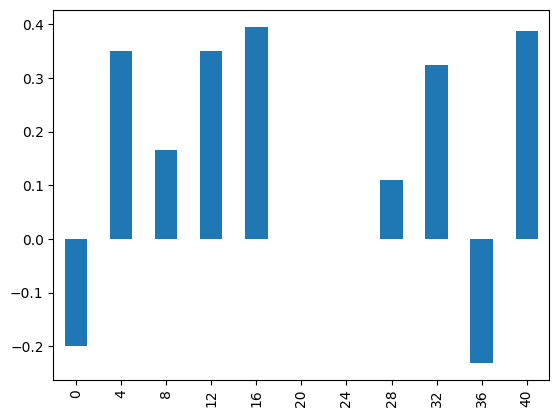

In [ ]:
# from live session on August 8, 2025
# use textblob to do sentiment analysis
from textblob import TextBlob
cleaner_tweets['Sentiment'] = cleaner_tweets['0'].apply(lambda x: TextBlob(x).sentiment.polarity).plot.bar()
print(cleaner_tweets['Sentiment'].describe())

count                              11
unique                              1
top       Axes(0.125,0.11;0.775x0.77)
freq                               11
Name: Sentiment, dtype: object


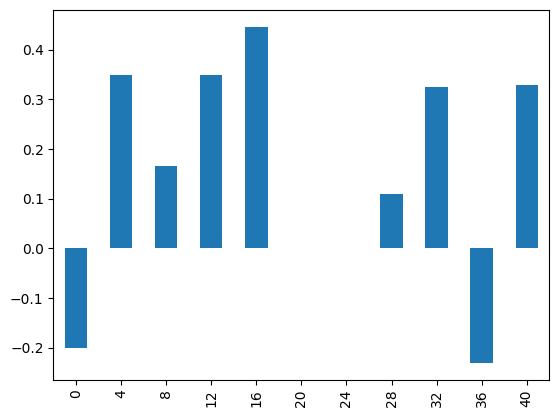

In [ ]:
# testing with the no_mentions df
from textblob import TextBlob
sentiment_df['Sentiment'] = sentiment_df['0'].apply(lambda x: TextBlob(x).sentiment.polarity).plot.bar()
print(sentiment_df['Sentiment'].describe())

count                              11
unique                              1
top       Axes(0.125,0.11;0.775x0.77)
freq                               11
Name: Sentiment, dtype: object


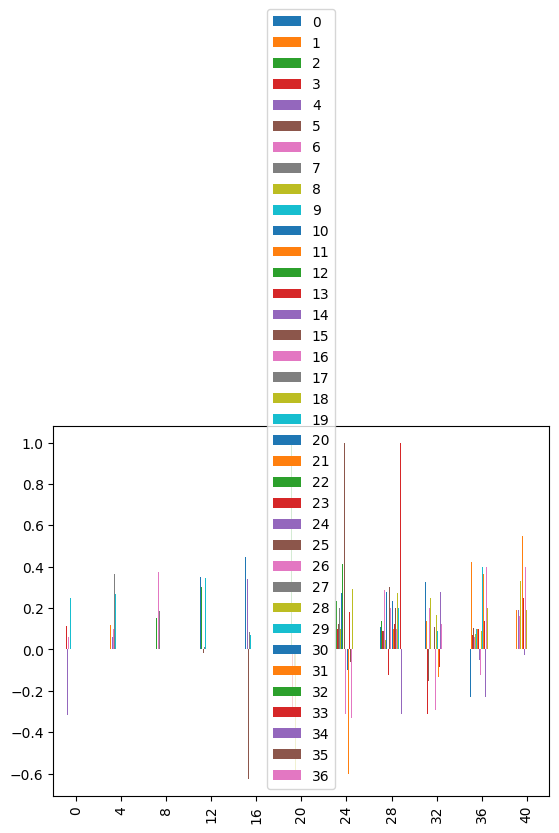

In [ ]:
# testing with map()
from textblob import TextBlob
sentiment_df['Sentiment'] = sentiment_df.map(lambda x: TextBlob(x).sentiment.polarity).plot.bar()
print(sentiment_df['Sentiment'].describe())

The legend was absurdly long and the plotted data looked uneven, so I opted to better organize the CSV file into rows of 10 tweets. The last row had 11 tweets, though.

In [ ]:
less_chaotic_df = pd.read_csv('tweets-only-better.csv').dropna(axis=1)

The cleaning process was done again on the newly organized tweets.

In [ ]:
pt.set_options(pt.OPT.URL, pt.OPT.EMOJI, pt.OPT.SMILEY, pt.OPT.MENTION)

no_mentions = pd.DataFrame()

for x in less_chaotic_df.columns:
  a_col = str(x)
  no_mentions[a_col] = less_chaotic_df[a_col].apply(pt.clean)

In [ ]:
# remove stop words from no_mentions with NLTK

nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
tweet_tokens = no_mentions.apply(lambda col: col.str.lower())

def remove_stopwords(text):
    if not isinstance(text, str):
        return ' '
    words = text.split()
    no_stops = [word for word in words if word.lower() not in stop_words]
    return ' '.join(no_stops)

sentiment_df = tweet_tokens.map(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Now the tweets can be plotted nicely! And I looked up how to move the legend to the side with plyplot.

count         20
unique         1
top       Legend
freq          20
Name: Sentiment, dtype: object


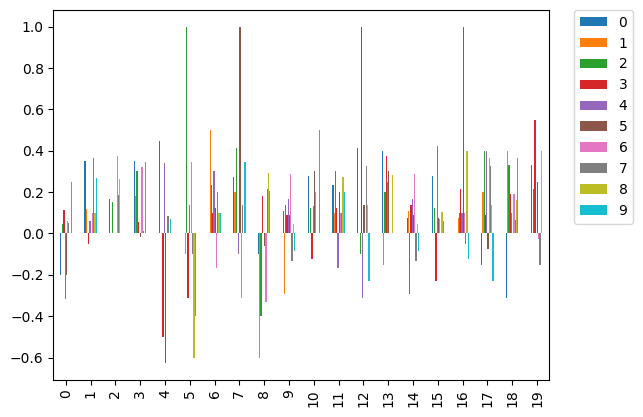

In [ ]:
from textblob import TextBlob
sentiment_df['Sentiment'] = sentiment_df.map(lambda x: TextBlob(x).sentiment.polarity).plot.bar().legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
print(sentiment_df['Sentiment'].describe())

After doing the word clouds, I noticed the polarity value for each tweet was not recorded in the "Sentiment" column, and that the values for graphing were appended to the end of each row. I tried to remove the appended values before plotting, but it didn't work.

In [ ]:
re.sub(r'<matplotlib.*>', '', str(preprocessed_tweets.values))

"[['rightthe apps users women share mens info without mens consent violate privacy laws lead defamation claims info false harmful platforms like tea may claim section  protection courts ruled similar doxxing sites'\n  'wait  know this victorian information commissioner opened investigation universitys surveillance propalestine staff students suspected breach privacy laws'\n  'check it new jersey gov phil murphy signs law creating digital id program tech digital data privacy'\n  'tea app data privacy breach every app web company honest conversation team ask do really need peoples personal information complete signup process comes serious ramifications including investing'\n  'never recommend express vpn one worst customer service experiences ever plus lot data privacyspying concerns quick google find dont ever type thing really hate them cost soo much money gaslit forever'\n  'solid choices lowlatency serverless try vercel edge functions nextjsthey minimize cold starts via global cachin

In [ ]:
preprocessed_tweets['Sentiment']

,Sentiment
0,Legend
1,Legend
2,Legend
3,Legend
4,Legend
5,Legend
6,Legend
7,Legend
8,Legend
9,Legend


Getting the overall polarity of the tweets felt like a useful value.

In [ ]:
# overall polarity of tweets
TextBlob(all_tweets2).sentiment.polarity

0.11903390005568423

## Word Cloud testing

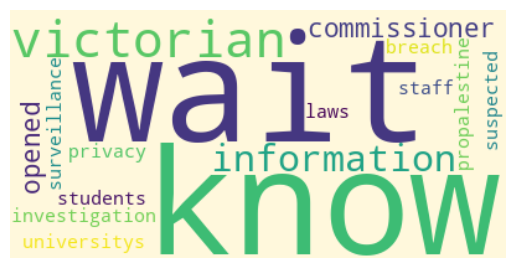

In [ ]:
# following DataCamp tutorial
# testing on first tweet

# string data
text = preprocessed_tweets.iloc[0,1]

# make the word cloud picture
wordcloud = WordCloud(background_color='cornsilk').generate(text)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

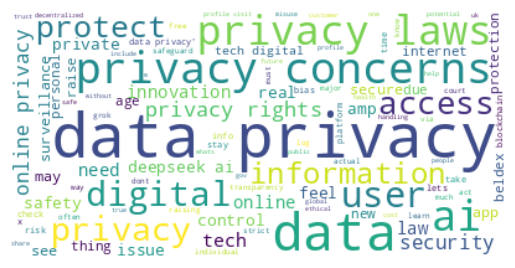

In [ ]:
# put all the tweets together
# no mentions

all_tweets = str(preprocessed_tweets.values)

all_tweets_cloud = WordCloud(background_color='white', max_words=100).generate(all_tweets)

plt.imshow(all_tweets_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
import re

test_string = str(preprocessed_tweets.values)

re.sub(r'<matplotlib.*>', '', test_string)

"[['rightthe apps users women share mens info without mens consent violate privacy laws lead defamation claims info false harmful platforms like tea may claim section  protection courts ruled similar doxxing sites'\n  'wait  know this victorian information commissioner opened investigation universitys surveillance propalestine staff students suspected breach privacy laws'\n  'check it new jersey gov phil murphy signs law creating digital id program tech digital data privacy'\n  'tea app data privacy breach every app web company honest conversation team ask do really need peoples personal information complete signup process comes serious ramifications including investing'\n  'never recommend express vpn one worst customer service experiences ever plus lot data privacyspying concerns quick google find dont ever type thing really hate them cost soo much money gaslit forever'\n  'solid choices lowlatency serverless try vercel edge functions nextjsthey minimize cold starts via global cachin

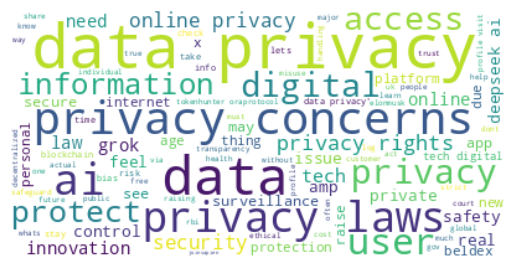

In [ ]:
# put all the tweets together
# with mentions

all_tweets = str(preprocessed_tweets2.values)

all_tweets_cloud = WordCloud(background_color='white', max_words=100).generate(all_tweets)

plt.imshow(all_tweets_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()